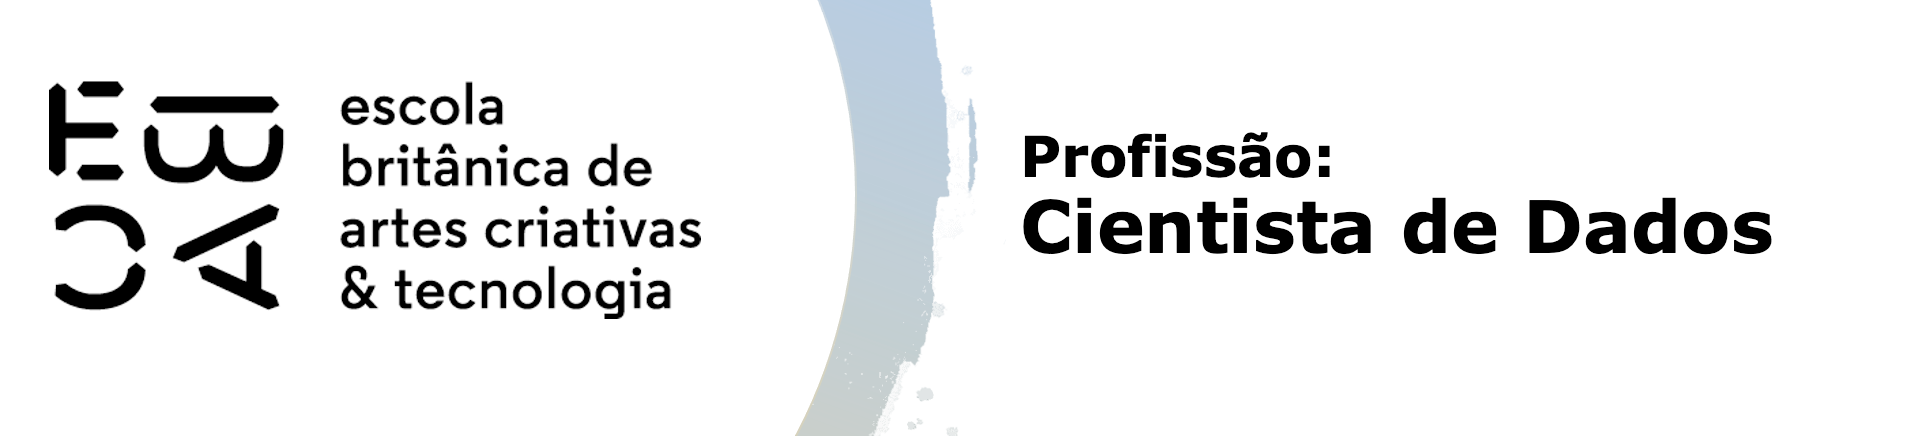

# Tarefa II

Neste projeto, estamos construindo um credit scoring para cartão de crédito, em um desenho amostral com 15 safras, e utilizando 12 meses de performance.

Carregue a base de dados ```credit_scoring.ftr```.

In [1]:
# 1) Importando bibliotecas

import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)
sns.set_theme(style='whitegrid')

print('Bibliotecas importadas com sucesso.')

Bibliotecas importadas com sucesso.


In [2]:
# 2) Carregando a base

# O notebook tenta primeiro o caminho indicado no modelo da atividade.
# Caso não encontre, tenta carregar o arquivo na mesma pasta do notebook.

caminhos_possiveis = [
    Path('../Dados/credit_scoring.ftr'),
    Path('credit_scoring.ftr')
]

for caminho in caminhos_possiveis:
    if caminho.exists():
        df = pd.read_feather(caminho)
        print('Arquivo carregado:', caminho)
        break
else:
    raise FileNotFoundError("Arquivo credit_scoring.ftr não encontrado. Coloque o arquivo em '../Dados/' ou na mesma pasta do notebook.")

print('Dimensão da base:', df.shape)
df.head()

Arquivo carregado: credit_scoring.ftr
Dimensão da base: (750000, 15)


,data_ref,index,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,renda,mau
0,2015-01-01,5733,F,N,N,0,Empresário,Médio,Solteiro,Casa,43,6.873973,1.0,2515.39,False
1,2015-01-01,727,F,S,S,0,Assalariado,Médio,Casado,Casa,35,4.526027,2.0,3180.19,False
2,2015-01-01,6374,F,N,N,2,Assalariado,Médio,Casado,Casa,31,0.243836,4.0,1582.29,False
3,2015-01-01,9566,F,N,N,0,Assalariado,Médio,Casado,Casa,54,12.772603,2.0,13721.17,False
4,2015-01-01,9502,F,S,N,0,Assalariado,Superior incompleto,Solteiro,Casa,31,8.432877,1.0,2891.08,False


## Amostragem

Separe os três últimos meses como safras de validação *out of time* (oot).

Variáveis:<br>
Considere que a variável ```data_ref``` não é uma variável explicativa, é somente uma variável indicadora da safra, e não deve ser utilizada na modelagem. A variávei ```index``` é um identificador do cliente, e também não deve ser utilizada como covariável (variável explicativa). As restantes podem ser utilizadas para prever a inadimplência, incluindo a renda.


In [3]:
# Ajustando data_ref e verificando as safras

df['data_ref'] = pd.to_datetime(df['data_ref'])

safras = (
    df['data_ref']
    .value_counts()
    .sort_index()
    .rename_axis('data_ref')
    .reset_index(name='qtd_linhas')
)

print('Quantidade de linhas por safra:')
safras.head()

Quantidade de linhas por safra:


,data_ref,qtd_linhas
0,2015-01-01,50000
1,2015-02-01,50000
2,2015-03-01,50000
3,2015-04-01,50000
4,2015-05-01,50000


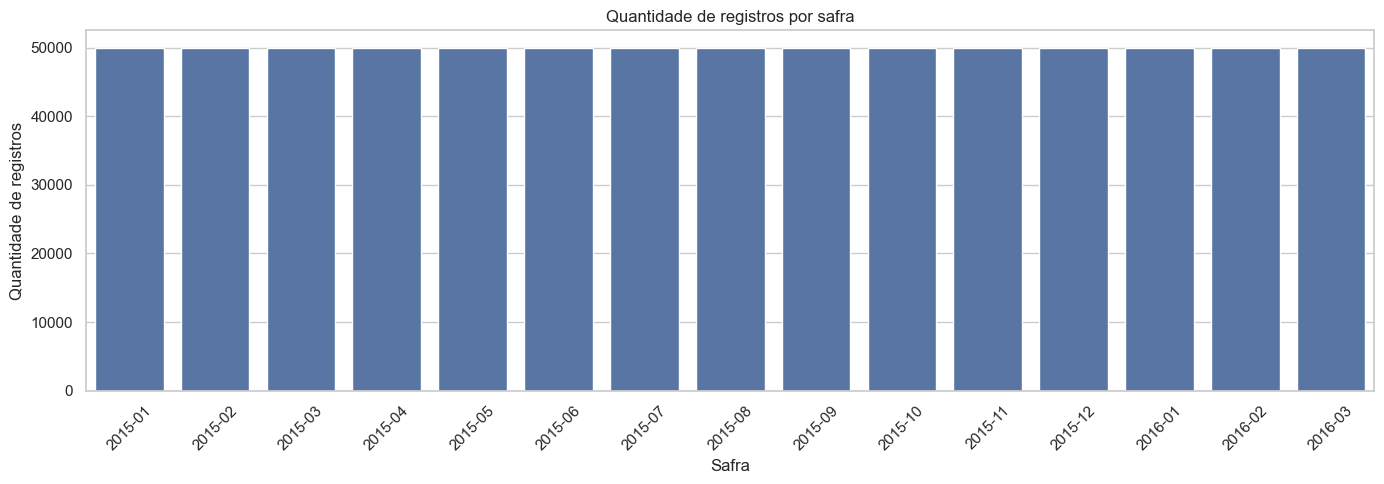

Total de safras: 15


In [4]:
# Visualizando quantidade de registros por safra

plt.figure(figsize=(14, 5))
sns.barplot(data=safras, x=safras['data_ref'].dt.strftime('%Y-%m'), y='qtd_linhas')
plt.title('Quantidade de registros por safra')
plt.xlabel('Safra')
plt.ylabel('Quantidade de registros')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('Total de safras:', safras.shape[0])

In [5]:
# Separando desenvolvimento e OOT

ultimas_3_safras = sorted(df['data_ref'].unique())[-3:]

base_oot = df[df['data_ref'].isin(ultimas_3_safras)].copy()
base_dev = df[~df['data_ref'].isin(ultimas_3_safras)].copy()

print('Safras utilizadas como OOT:')
print([pd.Timestamp(x).strftime('%Y-%m') for x in ultimas_3_safras])
print('Dimensão da base de desenvolvimento:', base_dev.shape)
print('Dimensão da base OOT:', base_oot.shape)
print('Taxa de mau - desenvolvimento:', round(base_dev['mau'].mean(), 4))
print('Taxa de mau - OOT:', round(base_oot['mau'].mean(), 4))

Safras utilizadas como OOT:
['2016-01', '2016-02', '2016-03']
Dimensão da base de desenvolvimento: (600000, 15)
Dimensão da base OOT: (150000, 15)
Taxa de mau - desenvolvimento: 0.0611
Taxa de mau - OOT: 0.1467


In [6]:
# Separando variáveis explicativas e resposta

variaveis_remover = ['data_ref', 'index', 'mau']

X_dev = base_dev.drop(columns=variaveis_remover)
y_dev = base_dev['mau']

X_oot = base_oot.drop(columns=variaveis_remover)
y_oot = base_oot['mau']

print('Dimensão de X_dev:', X_dev.shape)
print('Dimensão de X_oot:', X_oot.shape)
X_dev.head()

Dimensão de X_dev: (600000, 12)
Dimensão de X_oot: (150000, 12)


,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,renda
0,F,N,N,0,Empresário,Médio,Solteiro,Casa,43,6.873973,1.0,2515.39
1,F,S,S,0,Assalariado,Médio,Casado,Casa,35,4.526027,2.0,3180.19
2,F,N,N,2,Assalariado,Médio,Casado,Casa,31,0.243836,4.0,1582.29
3,F,N,N,0,Assalariado,Médio,Casado,Casa,54,12.772603,2.0,13721.17
4,F,S,N,0,Assalariado,Superior incompleto,Solteiro,Casa,31,8.432877,1.0,2891.08


## Descritiva básica univariada

- Descreva a base quanto ao número de linhas, número de linhas para cada mês em ```data_ref```.
- Faça uma descritiva básica univariada de cada variável. Considere as naturezas diferentes: qualitativas e quantitativas.

In [7]:
# Informações gerais da base

print('Número de linhas da base completa:', df.shape[0])
print('Número de colunas da base completa:', df.shape[1])
print('Número de linhas da base de desenvolvimento:', base_dev.shape[0])
print('Número de linhas da base OOT:', base_oot.shape[0])

resumo_tipos = pd.DataFrame({
    'variavel': df.columns,
    'tipo': df.dtypes.astype(str).values,
    'qtd_missing': df.isna().sum().values,
    'pct_missing': (df.isna().mean().values * 100).round(2)
})

print('Resumo dos tipos e valores ausentes:')
resumo_tipos.head()

Número de linhas da base completa: 750000
Número de colunas da base completa: 15
Número de linhas da base de desenvolvimento: 600000
Número de linhas da base OOT: 150000
Resumo dos tipos e valores ausentes:


,variavel,tipo,qtd_missing,pct_missing
0,data_ref,datetime64[ns],0,0.0
1,index,int64,0,0.0
2,sexo,object,0,0.0
3,posse_de_veiculo,object,0,0.0
4,posse_de_imovel,object,0,0.0


In [8]:
# Separando variáveis numéricas e categóricas

variaveis_numericas = X_dev.select_dtypes(include=['number']).columns.tolist()
variaveis_categoricas = X_dev.select_dtypes(exclude=['number']).columns.tolist()

print('Quantidade de variáveis numéricas:', len(variaveis_numericas))
print('Quantidade de variáveis categóricas:', len(variaveis_categoricas))
print('Variáveis numéricas:', variaveis_numericas)
print('Variáveis categóricas:', variaveis_categoricas)

Quantidade de variáveis numéricas: 5
Quantidade de variáveis categóricas: 7
Variáveis numéricas: ['qtd_filhos', 'idade', 'tempo_emprego', 'qt_pessoas_residencia', 'renda']
Variáveis categóricas: ['sexo', 'posse_de_veiculo', 'posse_de_imovel', 'tipo_renda', 'educacao', 'estado_civil', 'tipo_residencia']


In [9]:
# Descritiva das variáveis numéricas

desc_num = X_dev[variaveis_numericas].describe().T

print('Descritiva das variáveis numéricas:')
desc_num.head()

Descritiva das variáveis numéricas:


,count,mean,std,min,25%,50%,75%,max
qtd_filhos,600000.0,0.433210,0.739869,0.000000,0.000000,0.000000,1.000000,1.400000e+01
idade,600000.0,43.798530,11.230659,22.000000,34.000000,43.000000,53.000000,6.800000e+01
tempo_emprego,499125.0,7.747992,6.688576,0.117808,3.049315,6.046575,10.180822,4.290685e+01
qt_pessoas_residencia,600000.0,2.212122,0.903757,1.000000,2.000000,2.000000,3.000000,1.500000e+01
renda,600000.0,27222.844732,87377.875997,161.860000,4670.600000,9887.580000,21628.870000,4.083986e+06


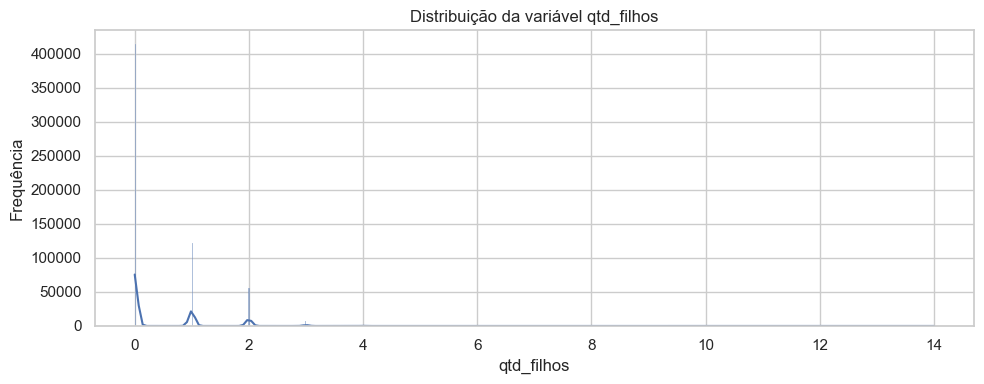

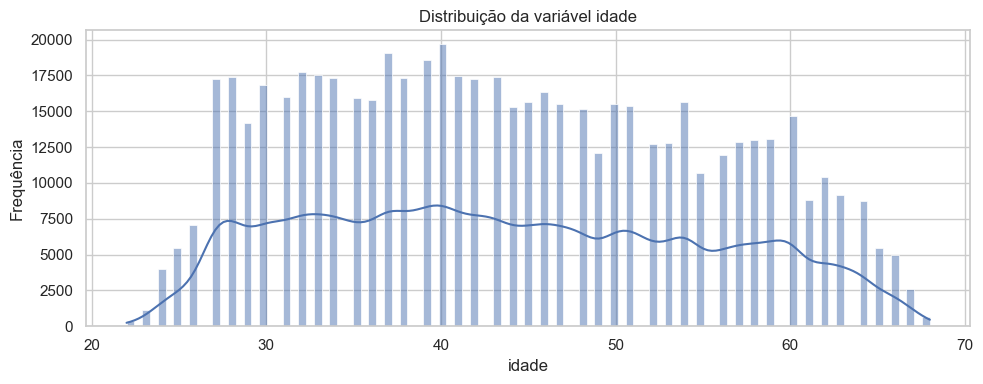

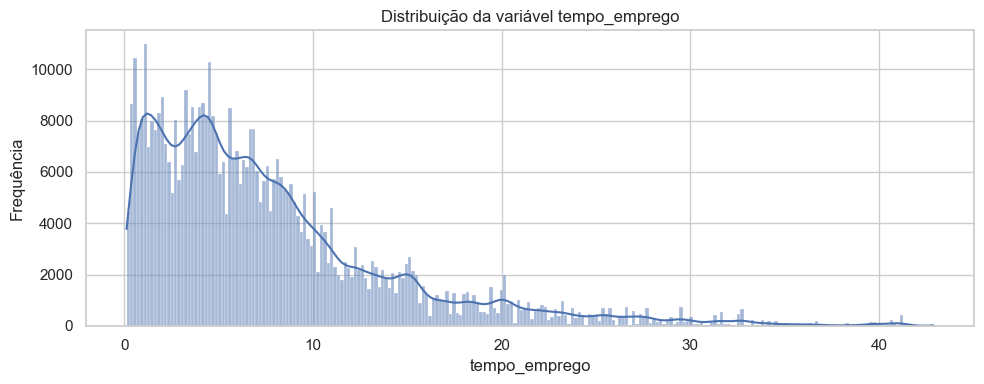

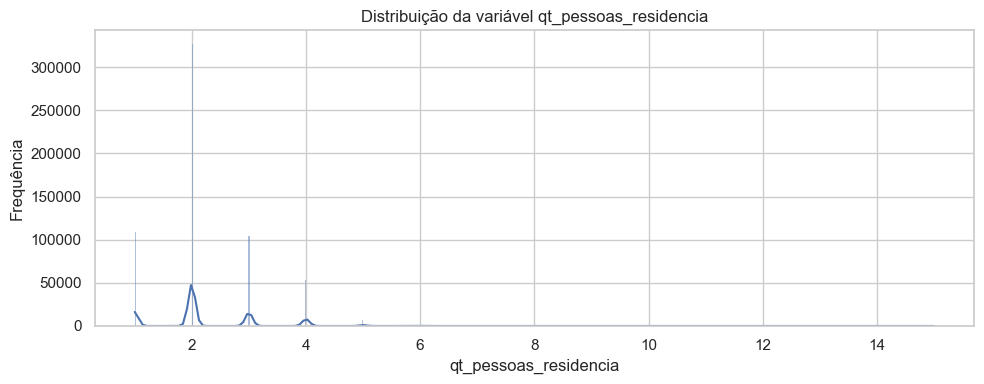

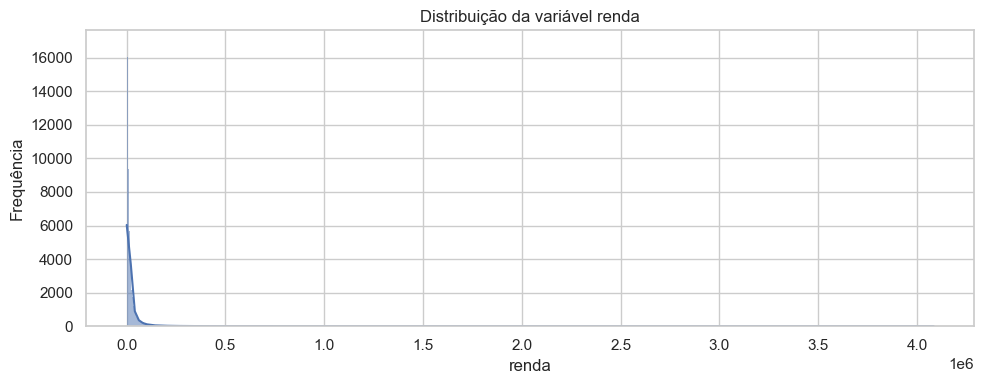

In [10]:
# Histogramas das variáveis numéricas

for var in variaveis_numericas:
    plt.figure(figsize=(10, 4))
    sns.histplot(X_dev[var], kde=True)
    plt.title(f'Distribuição da variável {var}')
    plt.xlabel(var)
    plt.ylabel('Frequência')
    plt.tight_layout()
    plt.show()

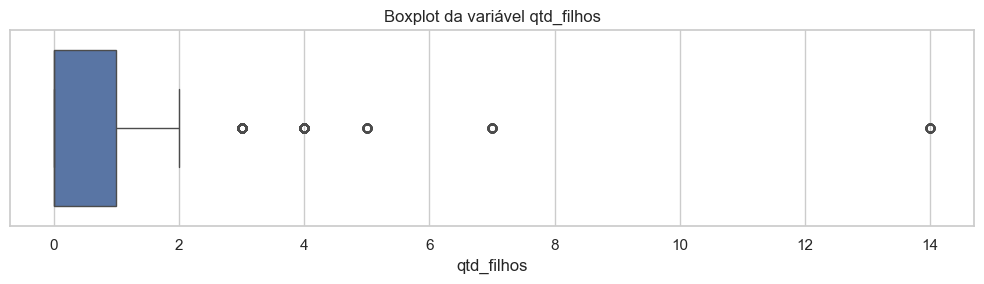

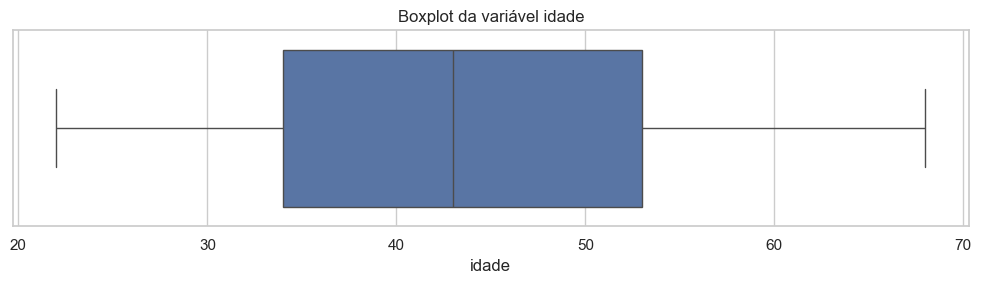

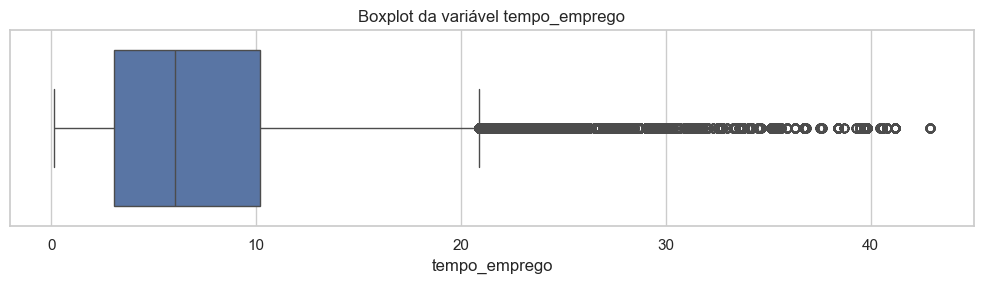

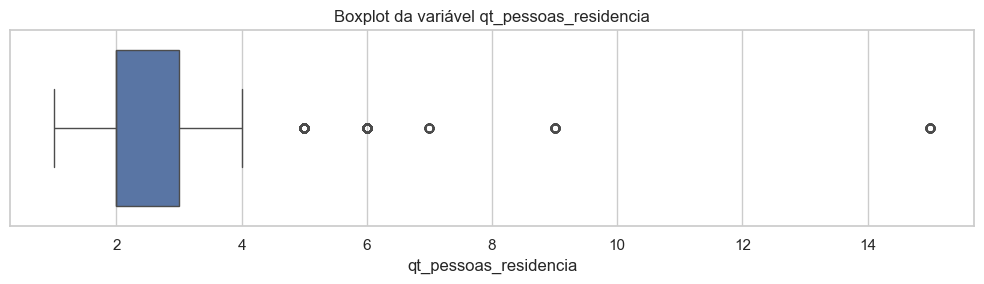

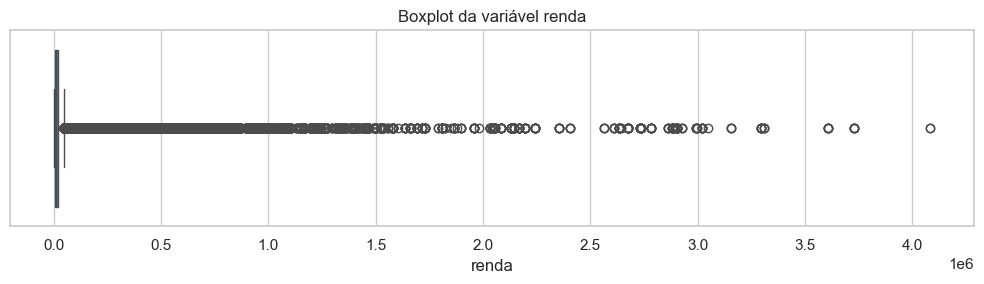

In [11]:
# Boxplots das variáveis numéricas

for var in variaveis_numericas:
    plt.figure(figsize=(10, 3))
    sns.boxplot(x=X_dev[var])
    plt.title(f'Boxplot da variável {var}')
    plt.xlabel(var)
    plt.tight_layout()
    plt.show()

Distribuição da variável sexo:


,sexo,qtd,pct
0,F,403805,67.3
1,M,196195,32.7


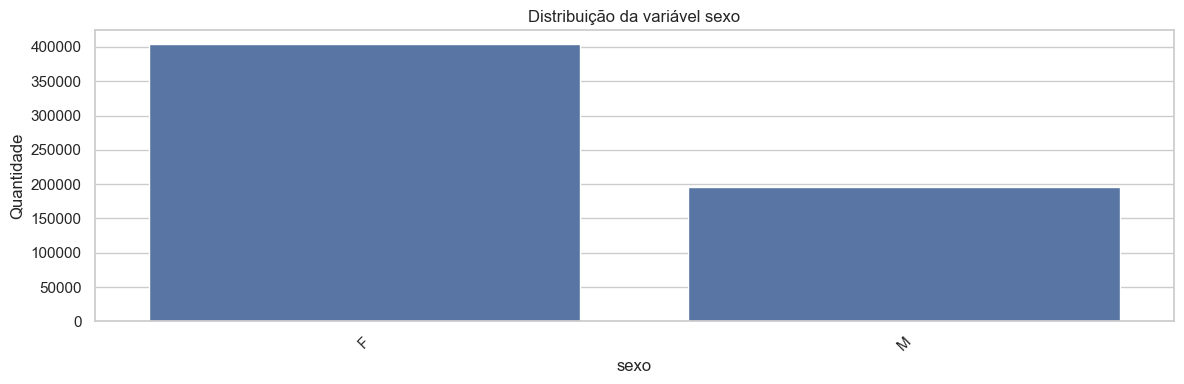

Distribuição da variável posse_de_veiculo:


,posse_de_veiculo,qtd,pct
0,N,366293,61.05
1,S,233707,38.95


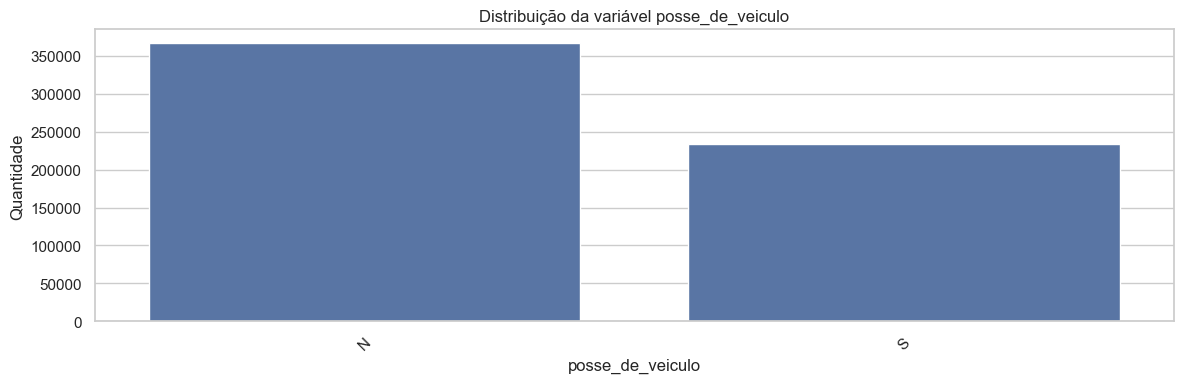

Distribuição da variável posse_de_imovel:


,posse_de_imovel,qtd,pct
0,S,403054,67.18
1,N,196946,32.82


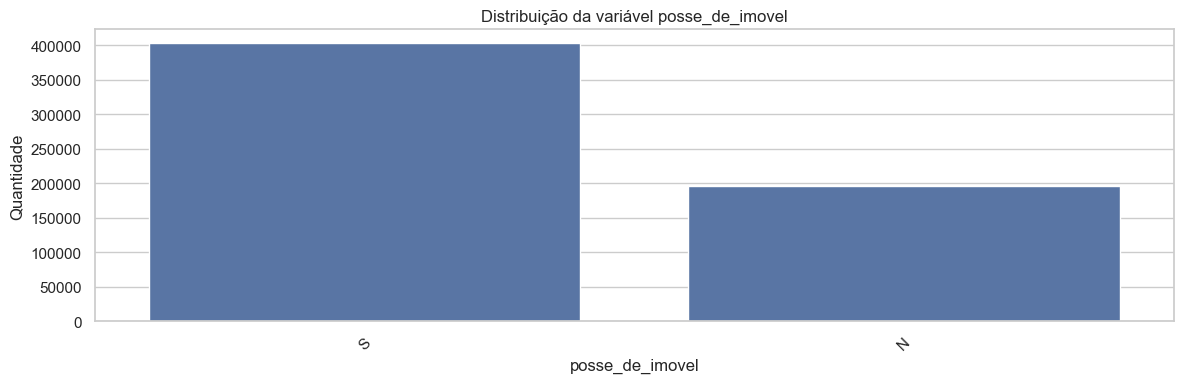

Distribuição da variável tipo_renda:


,tipo_renda,qtd,pct
0,Assalariado,308460,51.41
1,Empresário,138141,23.02
2,Pensionista,101127,16.85
3,Servidor público,51981,8.66
4,Bolsista,291,0.05


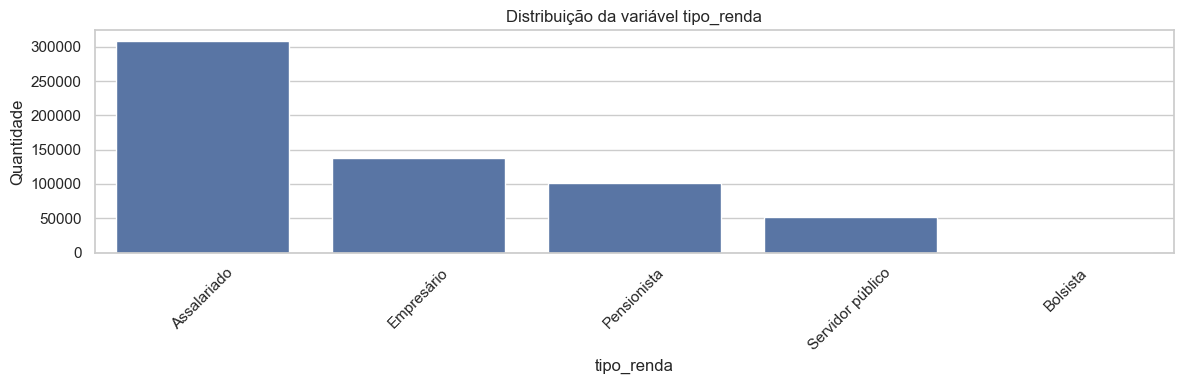

Distribuição da variável educacao:


,educacao,qtd,pct
0,Médio,405449,67.57
1,Superior completo,163440,27.24
2,Superior incompleto,23559,3.93
3,Fundamental,6901,1.15
4,Pós graduação,651,0.11


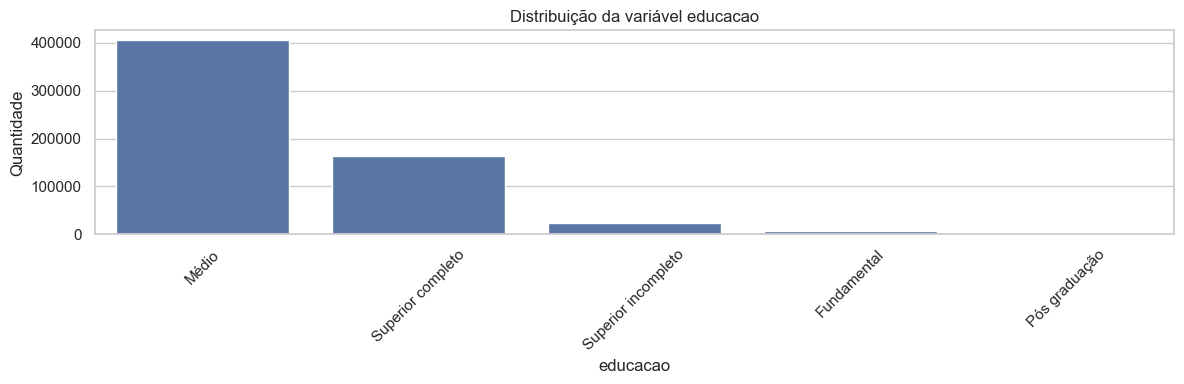

Distribuição da variável estado_civil:


,estado_civil,qtd,pct
0,Casado,421149,70.19
1,Solteiro,73221,12.20
2,União,46108,7.68
3,Separado,34188,5.70
4,Viúvo,25334,4.22


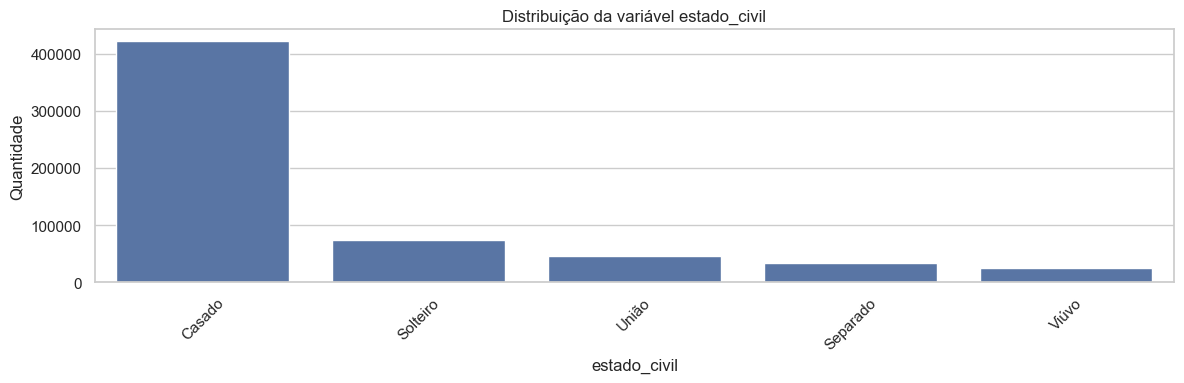

Distribuição da variável tipo_residencia:


,tipo_residencia,qtd,pct
0,Casa,539336,89.89
1,Com os pais,26730,4.46
2,Governamental,18742,3.12
3,Aluguel,8262,1.38
4,Estúdio,4296,0.72
5,Comunitário,2634,0.44


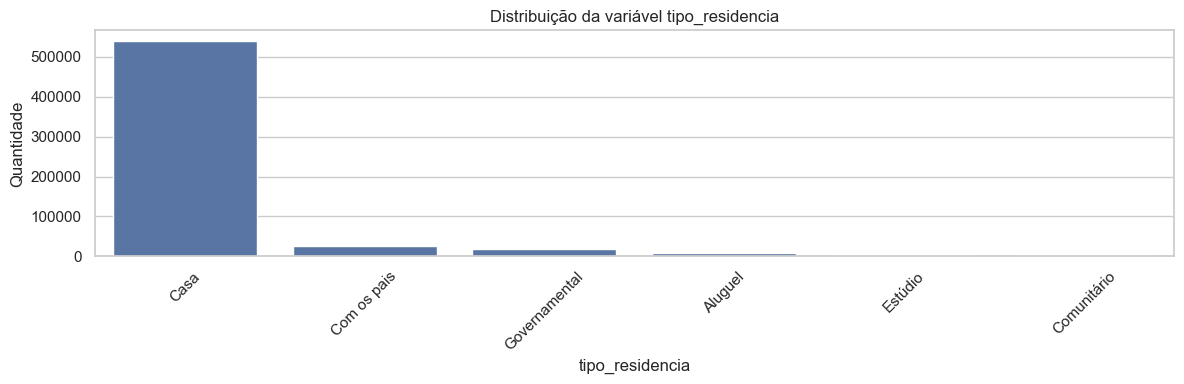

In [12]:
# Distribuição das variáveis categóricas

for var in variaveis_categoricas:
    tab = (
        X_dev[var]
        .astype('object')
        .fillna('Missing')
        .value_counts(dropna=False)
        .rename_axis(var)
        .reset_index(name='qtd')
    )
    tab['pct'] = (tab['qtd'] / tab['qtd'].sum() * 100).round(2)

    print(f'Distribuição da variável {var}:')
    display(tab)

    plt.figure(figsize=(12, 4))
    sns.barplot(data=tab, x=var, y='qtd')
    plt.title(f'Distribuição da variável {var}')
    plt.xlabel(var)
    plt.ylabel('Quantidade')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## Descritiva bivariada

Faça uma análise descritiva bivariada de cada variável

In [13]:
# Taxa de mau por safra

taxa_safra = (
    df.groupby('data_ref')['mau']
    .mean()
    .reset_index(name='taxa_mau')
)
taxa_safra['taxa_mau_pct'] = taxa_safra['taxa_mau'] * 100

print('Taxa de mau por safra:')
taxa_safra.head()

Taxa de mau por safra:


,data_ref,taxa_mau,taxa_mau_pct
0,2015-01-01,0.12114,12.114
1,2015-02-01,0.09868,9.868
2,2015-03-01,0.07356,7.356
3,2015-04-01,0.05326,5.326
4,2015-05-01,0.03702,3.702


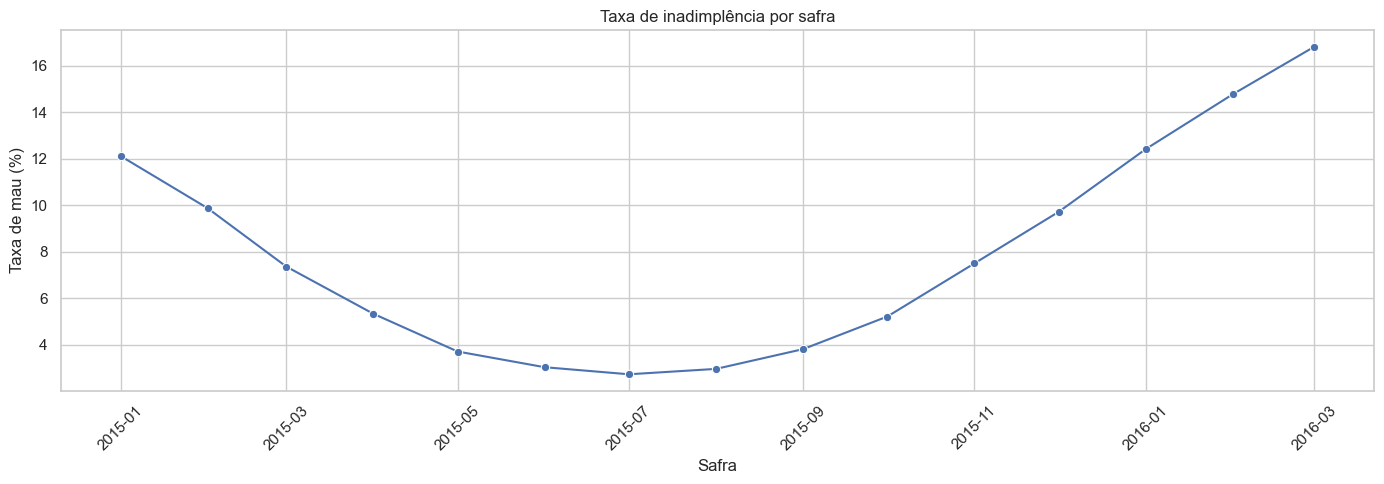

In [14]:
# Gráfico da taxa de mau por safra

plt.figure(figsize=(14, 5))
sns.lineplot(data=taxa_safra, x='data_ref', y='taxa_mau_pct', marker='o')
plt.title('Taxa de inadimplência por safra')
plt.xlabel('Safra')
plt.ylabel('Taxa de mau (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Bivariada da variável sexo:


,sexo,qtd,taxa_mau,taxa_mau_pct
0,F,403805,0.063117,6.31
1,M,196195,0.056862,5.69


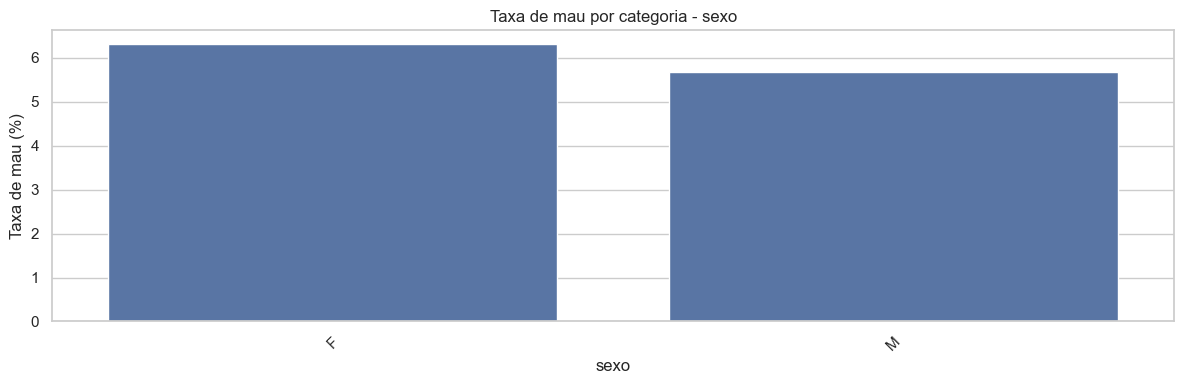

Bivariada da variável posse_de_veiculo:


,posse_de_veiculo,qtd,taxa_mau,taxa_mau_pct
0,N,366293,0.061467,6.15
1,S,233707,0.060452,6.05


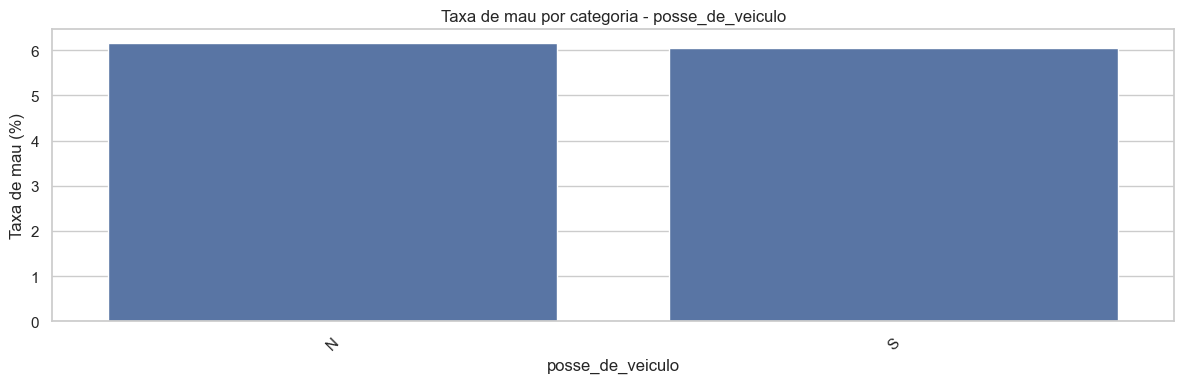

Bivariada da variável posse_de_imovel:


,posse_de_imovel,qtd,taxa_mau,taxa_mau_pct
0,N,196946,0.069263,6.93
1,S,403054,0.057069,5.71


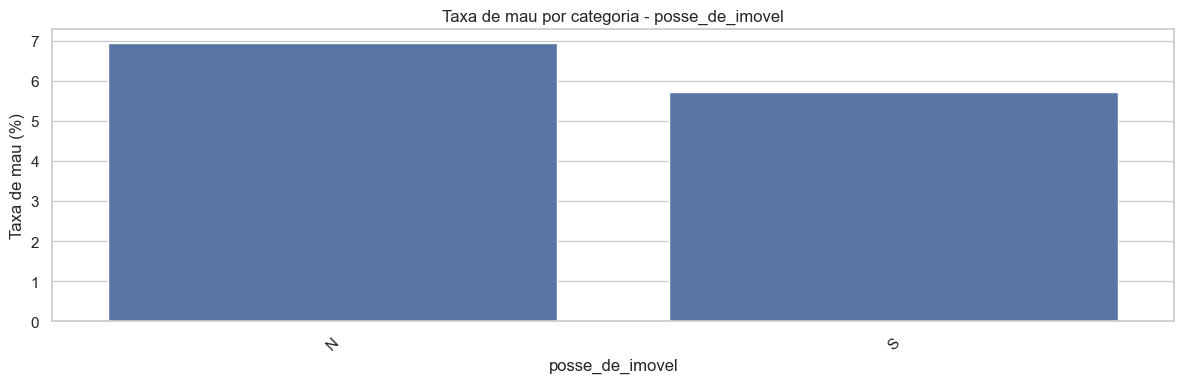

Bivariada da variável tipo_renda:


,tipo_renda,qtd,taxa_mau,taxa_mau_pct
3,Pensionista,101127,0.064276,6.43
0,Assalariado,308460,0.063525,6.35
2,Empresário,138141,0.059403,5.94
4,Servidor público,51981,0.044824,4.48
1,Bolsista,291,0.041237,4.12


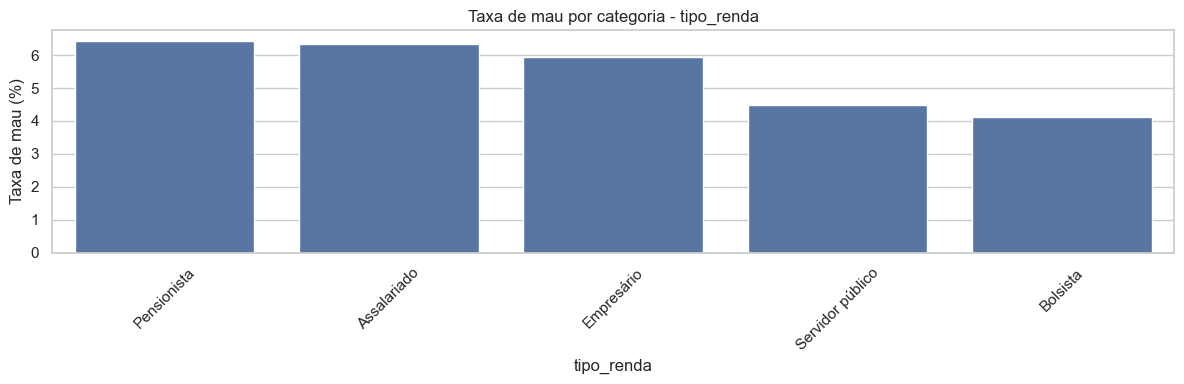

Bivariada da variável educacao:


,educacao,qtd,taxa_mau,taxa_mau_pct
0,Fundamental,6901,0.069700,6.97
2,Pós graduação,651,0.066052,6.61
4,Superior incompleto,23559,0.064646,6.46
1,Médio,405449,0.062918,6.29
3,Superior completo,163440,0.055592,5.56


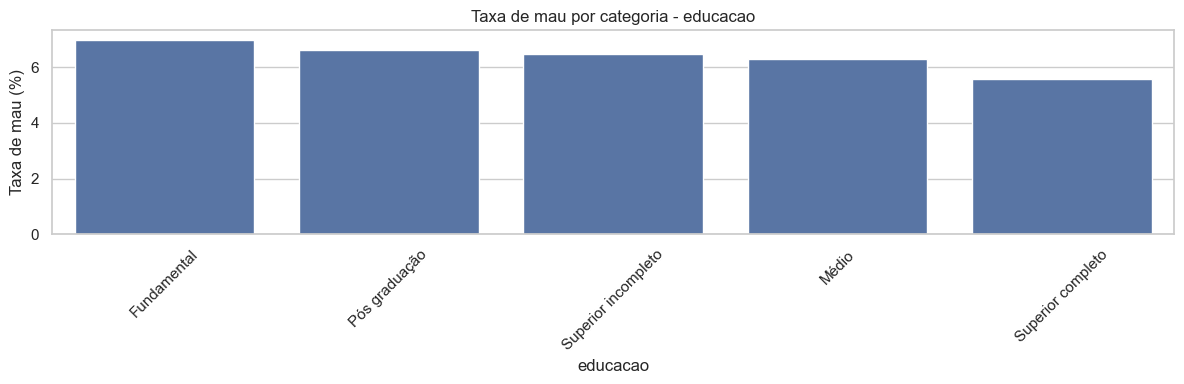

Bivariada da variável estado_civil:


,estado_civil,qtd,taxa_mau,taxa_mau_pct
3,União,46108,0.066366,6.64
1,Separado,34188,0.064175,6.42
2,Solteiro,73221,0.063315,6.33
0,Casado,421149,0.060000,6.00
4,Viúvo,25334,0.058577,5.86


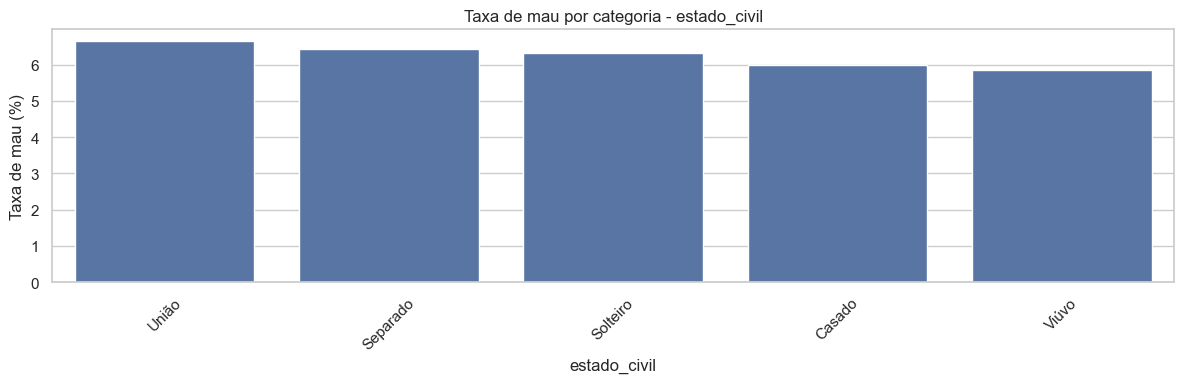

Bivariada da variável tipo_residencia:


,tipo_residencia,qtd,taxa_mau,taxa_mau_pct
2,Com os pais,26730,0.074710,7.47
0,Aluguel,8262,0.072137,7.21
3,Comunitário,2634,0.070235,7.02
5,Governamental,18742,0.063547,6.35
1,Casa,539336,0.060165,6.02
4,Estúdio,4296,0.052374,5.24


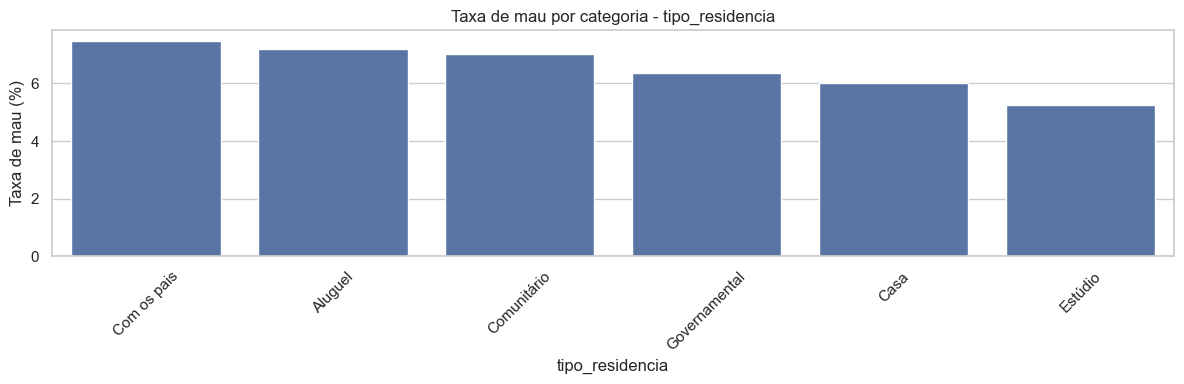

In [15]:
# Bivariada para variáveis categóricas

for var in variaveis_categoricas:
    tab = (
        base_dev.groupby(var, dropna=False)['mau']
        .agg(qtd='count', taxa_mau='mean')
        .reset_index()
        .sort_values('taxa_mau', ascending=False)
    )
    tab['taxa_mau_pct'] = (tab['taxa_mau'] * 100).round(2)

    print(f'Bivariada da variável {var}:')
    display(tab)

    plt.figure(figsize=(12, 4))
    sns.barplot(data=tab, x=var, y='taxa_mau_pct')
    plt.title(f'Taxa de mau por categoria - {var}')
    plt.xlabel(var)
    plt.ylabel('Taxa de mau (%)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Bivariada da variável qtd_filhos:


,faixa,qtd,taxa_mau,taxa_mau_pct
0,"(-0.001, 1.0]",536353,0.060924,6.09
1,"(1.0, 14.0]",63647,0.062312,6.23


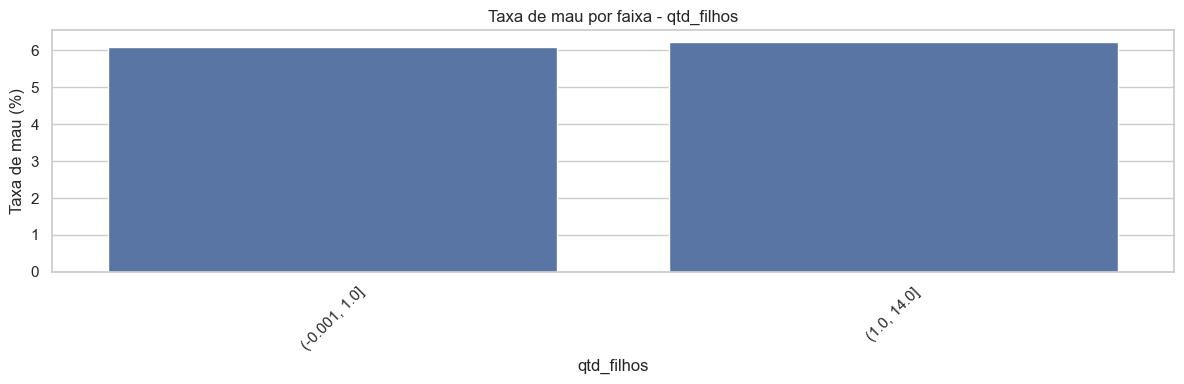

Bivariada da variável idade:


,faixa,qtd,taxa_mau,taxa_mau_pct
0,"(21.999, 33.0]",135135,0.074081,7.41
1,"(33.0, 40.0]",123702,0.062271,6.23
2,"(40.0, 47.0]",114926,0.056297,5.63
3,"(47.0, 55.0]",109960,0.051037,5.10
4,"(55.0, 68.0]",116277,0.058885,5.89


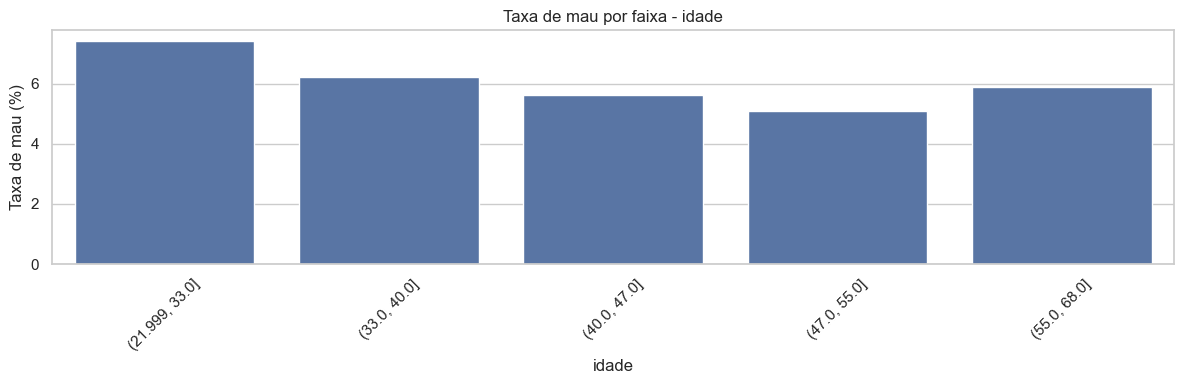

Bivariada da variável tempo_emprego:


,faixa,qtd,taxa_mau,taxa_mau_pct
0,"(0.11699999999999999, 2.364]",99884,0.102919,10.29
1,"(2.364, 4.693]",99968,0.080896,8.09
2,"(4.693, 7.458]",99718,0.060410,6.04
3,"(7.458, 11.726]",100152,0.042685,4.27
4,"(11.726, 42.907]",99403,0.015080,1.51


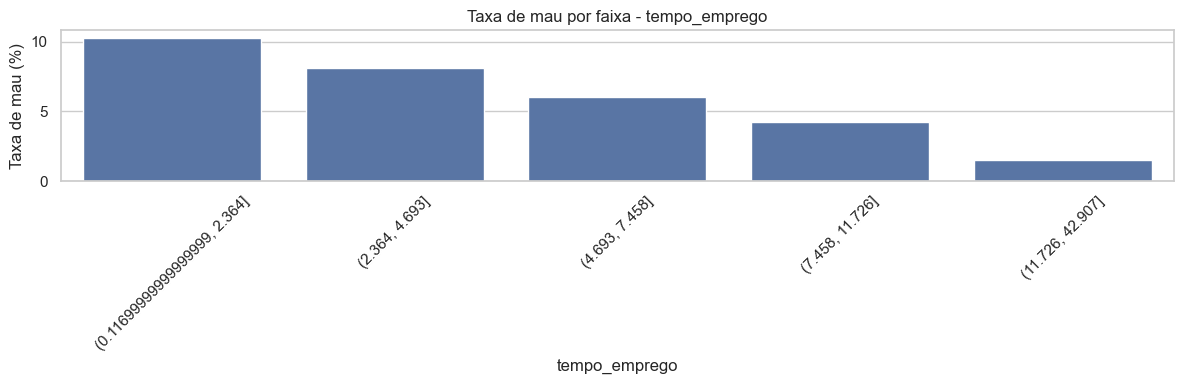

Bivariada da variável qt_pessoas_residencia:


,faixa,qtd,taxa_mau,taxa_mau_pct
0,"(0.999, 2.0]",434838,0.059907,5.99
1,"(2.0, 3.0]",104126,0.065334,6.53
2,"(3.0, 15.0]",61036,0.062095,6.21


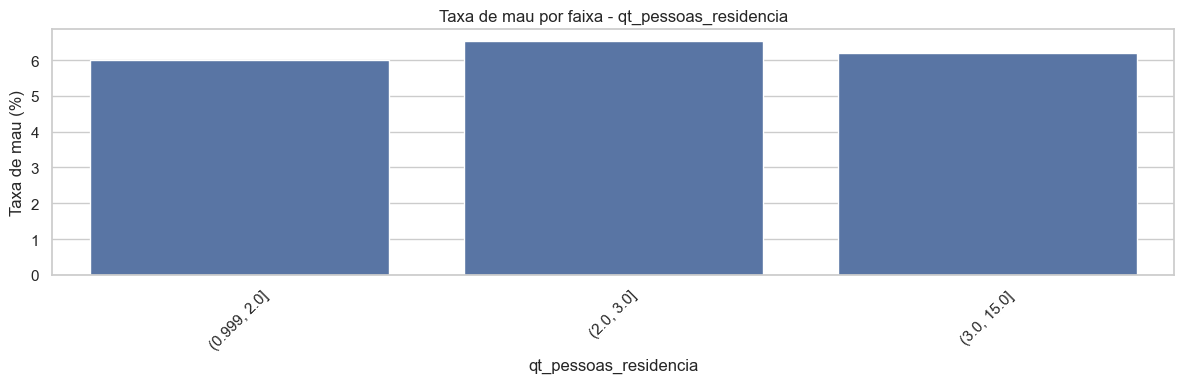

Bivariada da variável renda:


,faixa,qtd,taxa_mau,taxa_mau_pct
0,"(161.859, 3905.11]",120003,0.164988,16.50
1,"(3905.11, 7430.69]",119998,0.069276,6.93
2,"(7430.69, 13152.38]",120004,0.040557,4.06
3,"(13152.38, 26666.57]",120000,0.022367,2.24
4,"(26666.57, 4083986.22]",119995,0.008167,0.82


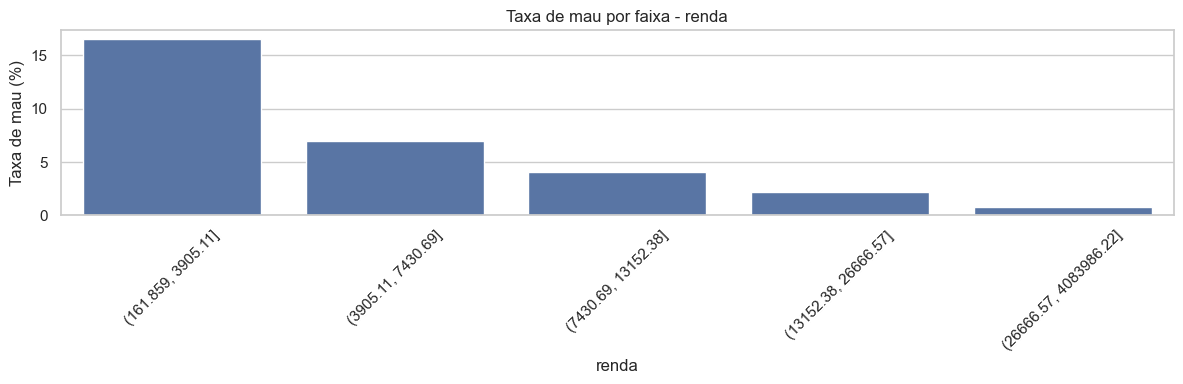

In [16]:
# Bivariada para variáveis numéricas

for var in variaveis_numericas:
    temp = base_dev[[var, 'mau']].dropna().copy()

    try:
        temp['faixa'] = pd.qcut(temp[var], q=5, duplicates='drop')

        tab = (
            temp.groupby('faixa')['mau']
            .agg(qtd='count', taxa_mau='mean')
            .reset_index()
        )
        tab['taxa_mau_pct'] = (tab['taxa_mau'] * 100).round(2)

        print(f'Bivariada da variável {var}:')
        display(tab)

        plt.figure(figsize=(12, 4))
        sns.barplot(data=tab, x='faixa', y='taxa_mau_pct')
        plt.title(f'Taxa de mau por faixa - {var}')
        plt.xlabel(var)
        plt.ylabel('Taxa de mau (%)')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    except Exception as erro:
        print(f'Não foi possível gerar faixas para {var}. Motivo: {erro}')

## Desenvolvimento do modelo

Desenvolva um modelo de *credit scoring* através de uma regressão logística.

- Trate valores missings e outliers
- Trate 'zeros estruturais'
- Faça agrupamentos de categorias conforme vimos em aula
- Proponha uma equação preditiva para 'mau'
- Caso hajam categorias não significantes, justifique

In [17]:
# Criando classes auxiliares para o pipeline

class AgrupadorCategoriasRaras(BaseEstimator, TransformerMixin):
    def __init__(self, limite=0.02):
        self.limite = limite
        self.categorias_validas_ = {}
        self.colunas_ = None

    def fit(self, X, y=None):
        X = pd.DataFrame(X).copy()
        self.colunas_ = X.columns.tolist()

        for col in self.colunas_:
            serie = X[col].astype('object').fillna('Missing')
            freq = serie.value_counts(normalize=True)
            self.categorias_validas_[col] = freq[freq >= self.limite].index.tolist()

        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        X.columns = self.colunas_

        for col in self.colunas_:
            serie = X[col].astype('object').fillna('Missing')
            validas = self.categorias_validas_[col]
            X[col] = np.where(serie.isin(validas), serie, 'Outros')

        return X

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = self.colunas_
        return np.asarray(input_features, dtype=object)


class TratadorZeroEstrutural(BaseEstimator, TransformerMixin):
    def __init__(self, colunas=None):
        self.colunas = colunas if colunas is not None else []
        self.colunas_ = None

    def fit(self, X, y=None):
        X = pd.DataFrame(X).copy()
        self.colunas_ = X.columns.tolist()
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()

        if self.colunas_ is not None:
            X.columns = self.colunas_

        for col in self.colunas:
            if col in X.columns:
                X[col] = X[col].replace(0, np.nan)

        return X

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = self.colunas_
        return np.asarray(input_features, dtype=object)


class LimitadorOutliers(BaseEstimator, TransformerMixin):
    def __init__(self, fator=1.5):
        self.fator = fator
        self.limites_ = {}
        self.colunas_ = None

    def fit(self, X, y=None):
        X = pd.DataFrame(X).copy()
        self.colunas_ = X.columns.tolist()

        for col in self.colunas_:
            q1 = X[col].quantile(0.25)
            q3 = X[col].quantile(0.75)
            iqr = q3 - q1

            limite_inf = q1 - self.fator * iqr
            limite_sup = q3 + self.fator * iqr

            self.limites_[col] = (limite_inf, limite_sup)

        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        X.columns = self.colunas_

        for col in self.colunas_:
            limite_inf, limite_sup = self.limites_[col]
            X[col] = X[col].clip(limite_inf, limite_sup)

        return X

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = self.colunas_
        return np.asarray(input_features, dtype=object)


print('Classes auxiliares criadas.')

Classes auxiliares criadas.


In [18]:
# Funções de avaliação do modelo

def calcular_metricas(y_true, probas, corte=0.5):
    pred = (probas >= corte).astype(int)
    acuracia = accuracy_score(y_true, pred)
    auc = roc_auc_score(y_true, probas)
    gini = 2 * auc - 1

    base_ks = pd.DataFrame({'y': y_true, 'score': probas}).sort_values('score')
    base_ks['bom'] = (base_ks['y'] == 0).astype(int)
    base_ks['mau'] = (base_ks['y'] == 1).astype(int)
    base_ks['cum_bom'] = base_ks['bom'].cumsum() / base_ks['bom'].sum()
    base_ks['cum_mau'] = base_ks['mau'].cumsum() / base_ks['mau'].sum()
    ks = np.max(np.abs(base_ks['cum_mau'] - base_ks['cum_bom']))

    return {
        'Acurácia': acuracia,
        'AUC': auc,
        'Gini': gini,
        'KS': ks
    }


def plotar_ks(y_true, probas, titulo):
    base_ks = pd.DataFrame({'y': y_true, 'score': probas}).sort_values('score')
    base_ks['bom'] = (base_ks['y'] == 0).astype(int)
    base_ks['mau'] = (base_ks['y'] == 1).astype(int)
    base_ks['cum_bom'] = base_ks['bom'].cumsum() / base_ks['bom'].sum()
    base_ks['cum_mau'] = base_ks['mau'].cumsum() / base_ks['mau'].sum()
    base_ks['ks'] = np.abs(base_ks['cum_mau'] - base_ks['cum_bom'])

    plt.figure(figsize=(10, 5))
    plt.plot(base_ks['cum_bom'].values, label='Bons acumulados')
    plt.plot(base_ks['cum_mau'].values, label='Maus acumulados')
    plt.title(titulo)
    plt.xlabel('Observações ordenadas pelo score')
    plt.ylabel('Distribuição acumulada')
    plt.legend()
    plt.tight_layout()
    plt.show()

print('Funções de avaliação criadas.')

Funções de avaliação criadas.


In [19]:
# Separando treino e teste dentro da base de desenvolvimento

X_train, X_test, y_train, y_test = train_test_split(
    X_dev,
    y_dev,
    test_size=0.30,
    random_state=42,
    stratify=y_dev
)

print('Dimensão de X_train:', X_train.shape)
print('Dimensão de X_test:', X_test.shape)
print('Taxa de mau no treino:', round(y_train.mean(), 4))
print('Taxa de mau no teste:', round(y_test.mean(), 4))

Dimensão de X_train: (420000, 12)
Dimensão de X_test: (180000, 12)
Taxa de mau no treino: 0.0611
Taxa de mau no teste: 0.0611


In [20]:
# Identificando possíveis zeros estruturais

colunas_zero_estrutural = []

for col in variaveis_numericas:
    serie = X_train[col].dropna()
    prop_zero = (serie == 0).mean() if len(serie) > 0 else 0

    if prop_zero >= 0.02 and serie.nunique() > 10:
        colunas_zero_estrutural.append(col)

print('Colunas tratadas como possível zero estrutural:')
print(colunas_zero_estrutural)

Colunas tratadas como possível zero estrutural:
[]


In [21]:
# Criando o pré-processamento da regressão logística

try:
    onehot = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown='ignore', sparse=False)

pipeline_numerico = Pipeline(steps=[
    ('zero_estrutural', TratadorZeroEstrutural(colunas=colunas_zero_estrutural)),
    ('imputer', SimpleImputer(strategy='median')),
    ('outliers', LimitadorOutliers()),
    ('scaler', StandardScaler())
])

pipeline_categorico = Pipeline(steps=[
    ('categorias_raras', AgrupadorCategoriasRaras(limite=0.02)),
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', onehot)
])

preprocessador_modelo = ColumnTransformer(transformers=[
    ('num', pipeline_numerico, variaveis_numericas),
    ('cat', pipeline_categorico, variaveis_categoricas)
])

modelo_reglog = Pipeline(steps=[
    ('preprocessador', preprocessador_modelo),
    ('modelo', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

modelo_reglog.fit(X_train, y_train)

print('Modelo de regressão logística treinado com sucesso.')

Modelo de regressão logística treinado com sucesso.


## Avaliação do modelo

Avalie o poder discriminante do modelo pelo menos avaliando acurácia, KS e Gini.

Avalie estas métricas nas bases de desenvolvimento e *out of time*.

In [22]:
# Gerando probabilidades previstas

proba_train = modelo_reglog.predict_proba(X_train)[:, 1]
proba_test = modelo_reglog.predict_proba(X_test)[:, 1]
proba_dev = modelo_reglog.predict_proba(X_dev)[:, 1]
proba_oot = modelo_reglog.predict_proba(X_oot)[:, 1]

metricas_reglog = pd.DataFrame({
    'Treino': calcular_metricas(y_train, proba_train),
    'Teste': calcular_metricas(y_test, proba_test),
    'Desenvolvimento': calcular_metricas(y_dev, proba_dev),
    'OOT': calcular_metricas(y_oot, proba_oot)
}).T

print('Métricas da regressão logística:')
metricas_reglog.head()

Métricas da regressão logística:


,Acurácia,AUC,Gini,KS
Treino,0.562319,0.765686,0.531372,0.394482
Teste,0.560311,0.764268,0.528536,0.394445
Desenvolvimento,0.561717,0.765261,0.530523,0.393800
OOT,0.303627,0.722028,0.444056,0.325540


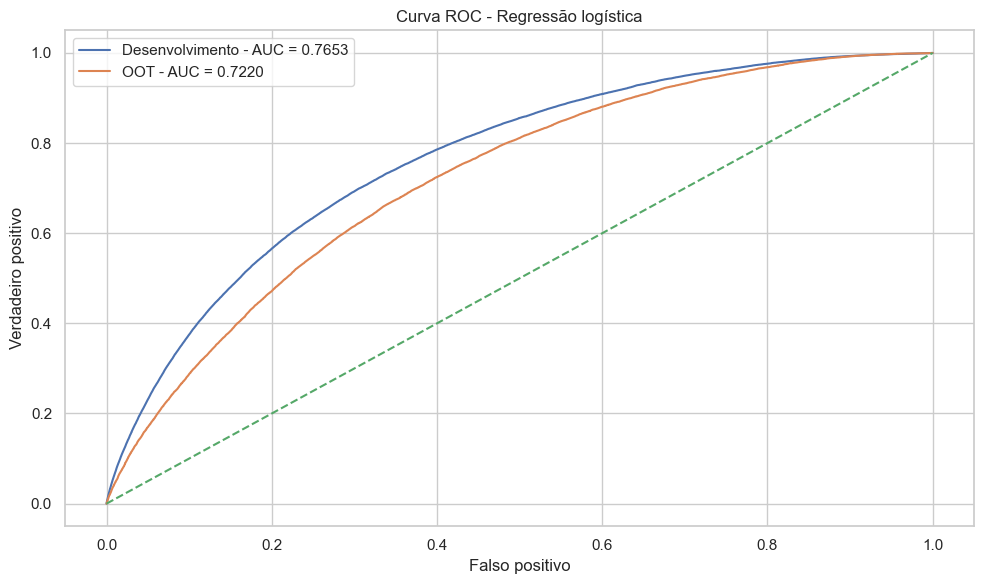

In [23]:
# Curva ROC da regressão logística

fpr_dev, tpr_dev, _ = roc_curve(y_dev, proba_dev)
fpr_oot, tpr_oot, _ = roc_curve(y_oot, proba_oot)

auc_dev = roc_auc_score(y_dev, proba_dev)
auc_oot = roc_auc_score(y_oot, proba_oot)

plt.figure(figsize=(10, 6))
plt.plot(fpr_dev, tpr_dev, label=f'Desenvolvimento - AUC = {auc_dev:.4f}')
plt.plot(fpr_oot, tpr_oot, label=f'OOT - AUC = {auc_oot:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title('Curva ROC - Regressão logística')
plt.xlabel('Falso positivo')
plt.ylabel('Verdadeiro positivo')
plt.legend()
plt.tight_layout()
plt.show()

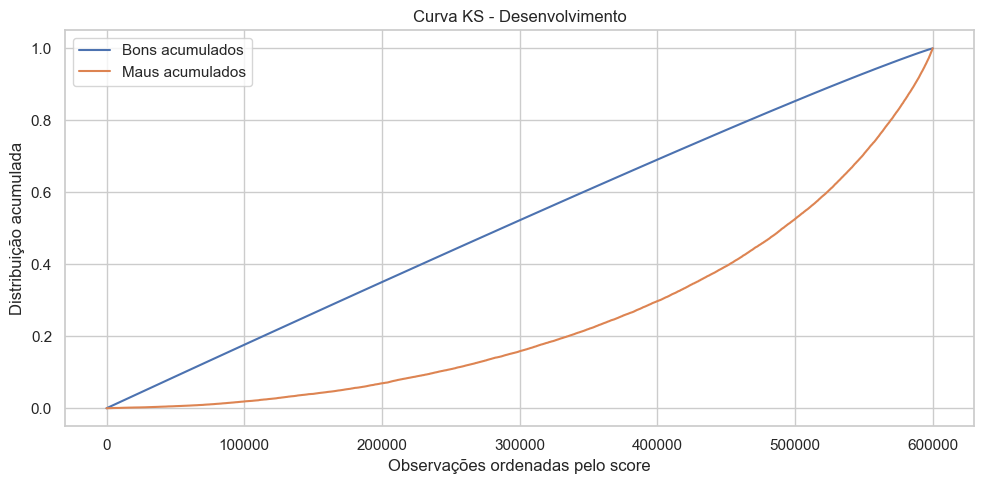

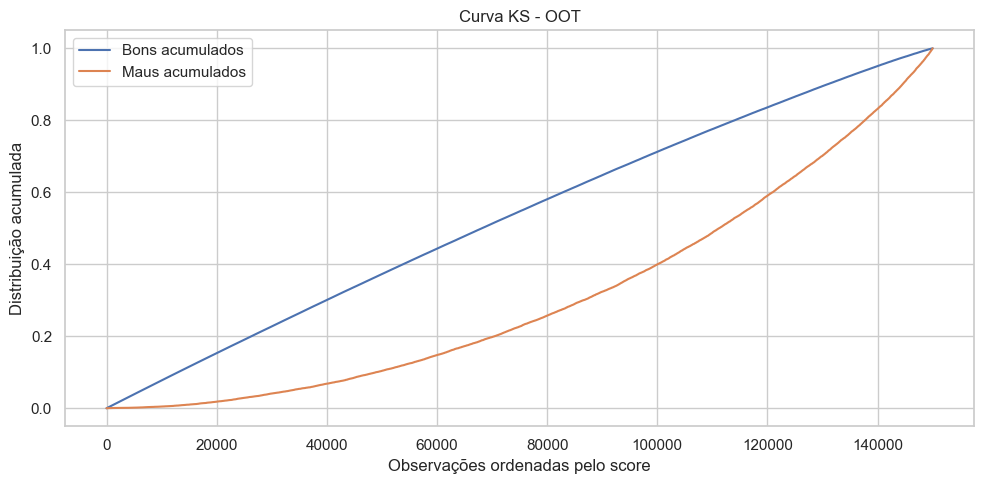

In [24]:
# Curvas KS

plotar_ks(y_dev, proba_dev, 'Curva KS - Desenvolvimento')
plotar_ks(y_oot, proba_oot, 'Curva KS - OOT')

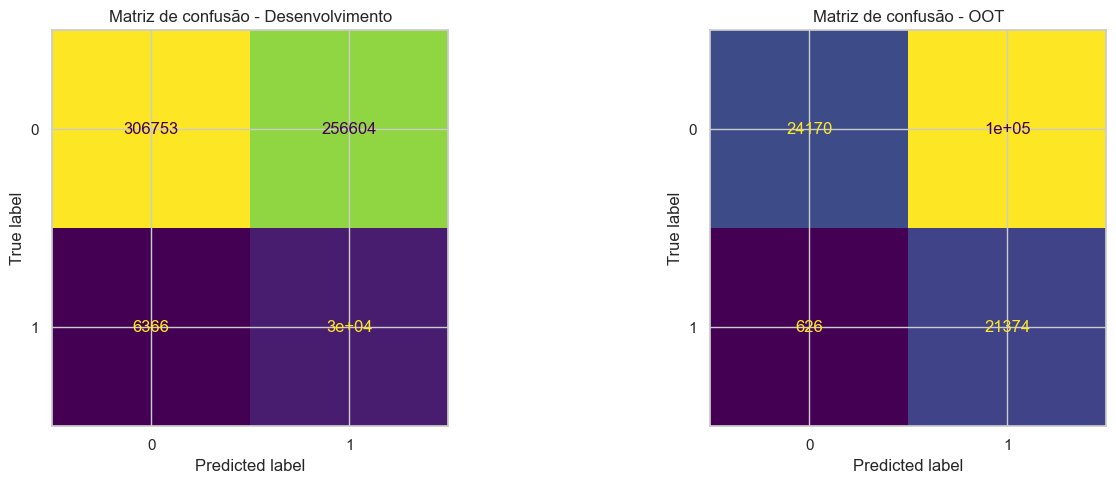

In [25]:
# Matrizes de confusão

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_dev = confusion_matrix(y_dev, (proba_dev >= 0.5).astype(int))
cm_oot = confusion_matrix(y_oot, (proba_oot >= 0.5).astype(int))

ConfusionMatrixDisplay(cm_dev).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Matriz de confusão - Desenvolvimento')

ConfusionMatrixDisplay(cm_oot).plot(ax=axes[1], colorbar=False)
axes[1].set_title('Matriz de confusão - OOT')

plt.tight_layout()
plt.show()

In [26]:
# Coeficientes e equação preditiva resumida

nomes_features = modelo_reglog.named_steps['preprocessador'].get_feature_names_out()
coeficientes = modelo_reglog.named_steps['modelo'].coef_[0]
intercepto = modelo_reglog.named_steps['modelo'].intercept_[0]

coef_df = pd.DataFrame({
    'variavel': nomes_features,
    'coeficiente': coeficientes,
    'abs_coef': np.abs(coeficientes)
}).sort_values('abs_coef', ascending=False)

print('Intercepto:', round(intercepto, 6))
print('Coeficientes mais relevantes:')
coef_df.head(20)

Intercepto: -0.173965
Coeficientes mais relevantes:


,variavel,coeficiente,abs_coef
4,num__renda,-1.367663,1.367663
6,cat__sexo_M,-0.147651,0.147651
10,cat__posse_de_imovel_S,-0.135669,0.135669
7,cat__posse_de_veiculo_N,-0.105176,0.105176
2,num__tempo_emprego,-0.100565,0.100565
14,cat__tipo_renda_Pensionista,-0.096843,0.096843
27,cat__tipo_residencia_Governamental,-0.094595,0.094595
20,cat__estado_civil_Casado,-0.073836,0.073836
19,cat__educacao_Superior incompleto,-0.069479,0.069479
8,cat__posse_de_veiculo_S,-0.068686,0.068686


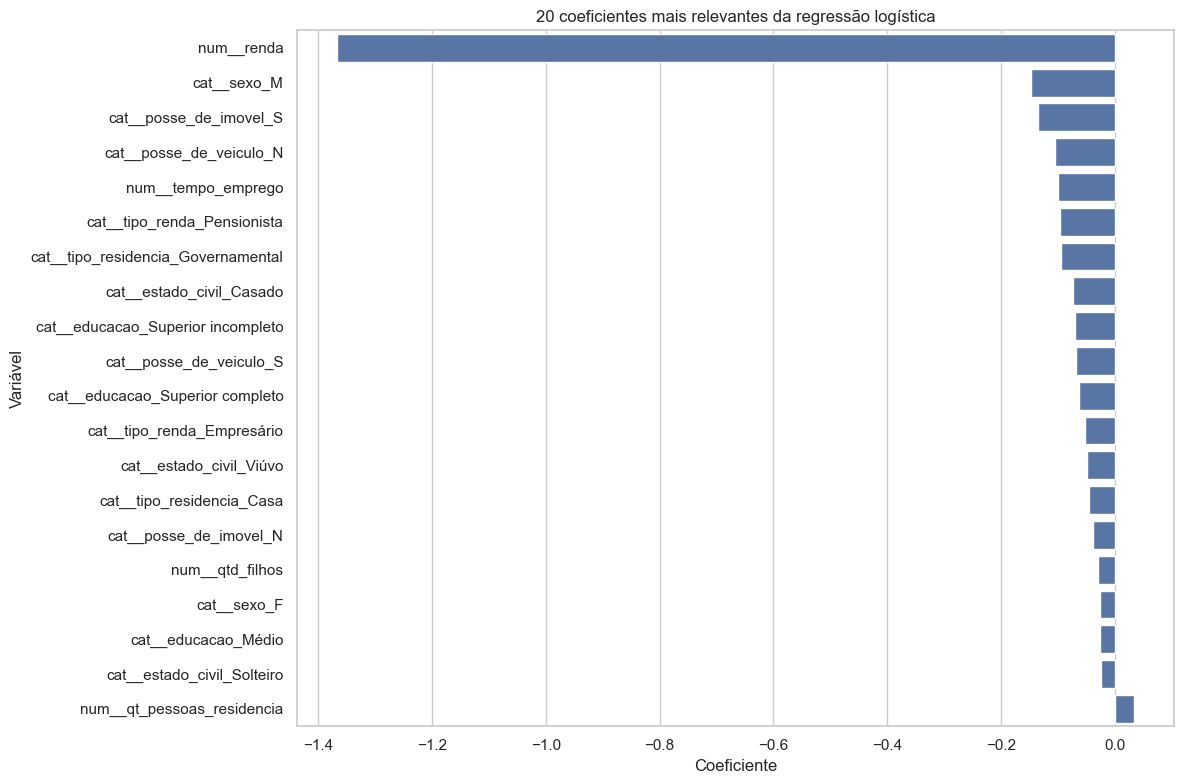

Equação preditiva resumida:
logit(P(mau=1)) = -0.1740 + (-1.3677 * num__renda) + (-0.1477 * cat__sexo_M) + (-0.1357 * cat__posse_de_imovel_S) + (-0.1052 * cat__posse_de_veiculo_N) + (-0.1006 * num__tempo_emprego) + (-0.0968 * cat__tipo_renda_Pensionista) + (-0.0946 * cat__tipo_residencia_Governamental) + (-0.0738 * cat__estado_civil_Casado) + (-0.0695 * cat__educacao_Superior incompleto) + (-0.0687 * cat__posse_de_veiculo_S)


In [27]:
# Gráfico dos coeficientes mais relevantes

top_coef = coef_df.head(20).sort_values('coeficiente')

plt.figure(figsize=(12, 8))
sns.barplot(data=top_coef, x='coeficiente', y='variavel')
plt.title('20 coeficientes mais relevantes da regressão logística')
plt.xlabel('Coeficiente')
plt.ylabel('Variável')
plt.tight_layout()
plt.show()

termos = [f"({linha.coeficiente:.4f} * {linha.variavel})" for _, linha in coef_df.head(10).iterrows()]
equacao = ' + '.join(termos)
print('Equação preditiva resumida:')
print(f'logit(P(mau=1)) = {intercepto:.4f} + {equacao}')

## Criar um pipeline utilizando o sklearn pipeline 

## Pré processamento

### Substituição de nulos (nans)

Existe nulos na base? é dado numérico ou categórico? qual o valor de substituição? média? valor mais frequente? etc

In [28]:
# Verificando valores nulos na base de desenvolvimento

nulos = pd.DataFrame({
    'tipo': X_dev.dtypes,
    'qtd_nulos': X_dev.isna().sum(),
    'perc_nulos': (X_dev.isna().mean() * 100).round(2)
}).sort_values('perc_nulos', ascending=False)

print('Resumo de valores nulos por variável:')
nulos

Resumo de valores nulos por variável:


,tipo,qtd_nulos,perc_nulos
tempo_emprego,float64,100875,16.81
sexo,object,0,0.00
posse_de_veiculo,object,0,0.00
posse_de_imovel,object,0,0.00
qtd_filhos,int64,0,0.00
tipo_renda,object,0,0.00
educacao,object,0,0.00
estado_civil,object,0,0.00
tipo_residencia,object,0,0.00
idade,int64,0,0.00


In [29]:
# Separando variáveis numéricas e categóricas para o pipeline

variaveis_numericas = X_dev.select_dtypes(include=['int64', 'int32', 'float64', 'float32']).columns.tolist()
variaveis_categoricas = X_dev.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print('Variáveis numéricas:')
print(variaveis_numericas)

print('\nVariáveis categóricas:')
print(variaveis_categoricas)

Variáveis numéricas:
['qtd_filhos', 'idade', 'tempo_emprego', 'qt_pessoas_residencia', 'renda']

Variáveis categóricas:
['sexo', 'posse_de_veiculo', 'posse_de_imovel', 'tipo_renda', 'educacao', 'estado_civil', 'tipo_residencia']


### Remoção de outliers

Como identificar outlier? Substituir o outlier por algum valor? Remover a linha?

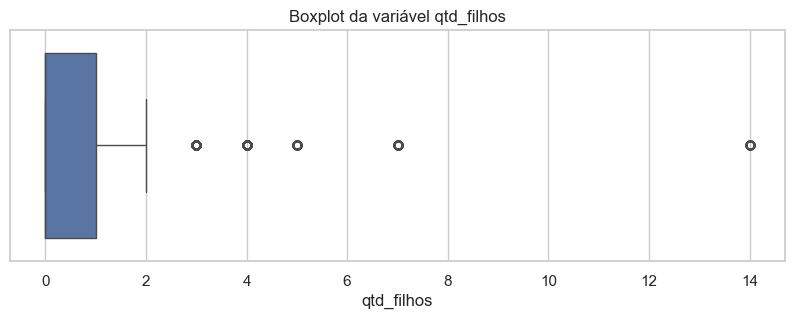

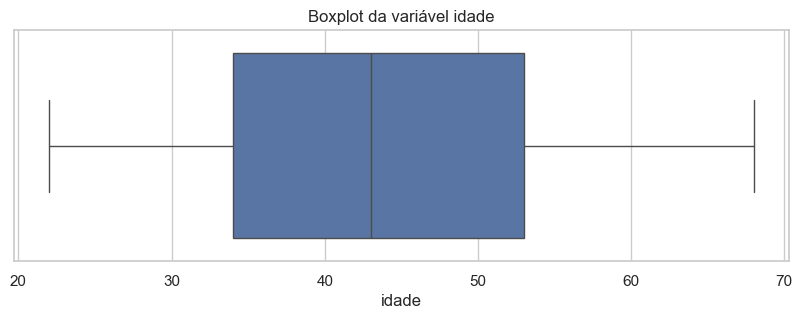

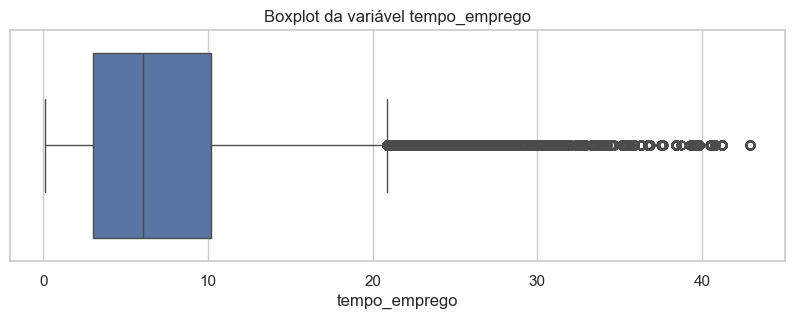

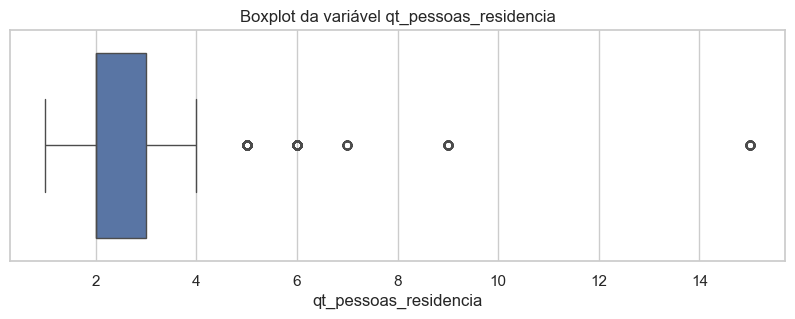

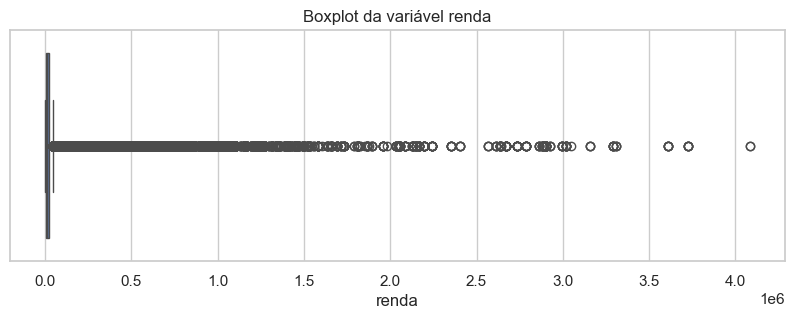

In [30]:
# Visualizando outliers das variáveis numéricas por boxplot

for col in variaveis_numericas:
    plt.figure(figsize=(10, 3))
    sns.boxplot(x=X_dev[col])
    plt.title(f'Boxplot da variável {col}')
    plt.xlabel(col)
    plt.show()

In [31]:
# Identificando limites pelo método IQR

limites_outliers = {}

for col in variaveis_numericas:
    q1 = X_dev[col].quantile(0.25)
    q3 = X_dev[col].quantile(0.75)
    iqr = q3 - q1
    
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    
    limites_outliers[col] = [limite_inferior, limite_superior]

limites_outliers = pd.DataFrame(limites_outliers, index=['limite_inferior', 'limite_superior']).T

print('Limites de outliers calculados pelo método IQR:')
limites_outliers

Limites de outliers calculados pelo método IQR:


,limite_inferior,limite_superior
qtd_filhos,-1.500000,2.500000
idade,5.500000,81.500000
tempo_emprego,-7.647945,20.878082
qt_pessoas_residencia,0.500000,4.500000
renda,-20766.805000,47066.275000


### Seleção de variáveis

Qual tipo de técnica? Boruta? Feature importance? 

In [32]:
# Seleção de variáveis usando importância da regressão logística já ajustada

coef_importancia = coef_df.copy()
coef_importancia = coef_importancia.sort_values('abs_coef', ascending=False)

print('Variáveis mais relevantes segundo os coeficientes da regressão logística:')
coef_importancia.head(20)

Variáveis mais relevantes segundo os coeficientes da regressão logística:


,variavel,coeficiente,abs_coef
4,num__renda,-1.367663,1.367663
6,cat__sexo_M,-0.147651,0.147651
10,cat__posse_de_imovel_S,-0.135669,0.135669
7,cat__posse_de_veiculo_N,-0.105176,0.105176
2,num__tempo_emprego,-0.100565,0.100565
14,cat__tipo_renda_Pensionista,-0.096843,0.096843
27,cat__tipo_residencia_Governamental,-0.094595,0.094595
20,cat__estado_civil_Casado,-0.073836,0.073836
19,cat__educacao_Superior incompleto,-0.069479,0.069479
8,cat__posse_de_veiculo_S,-0.068686,0.068686


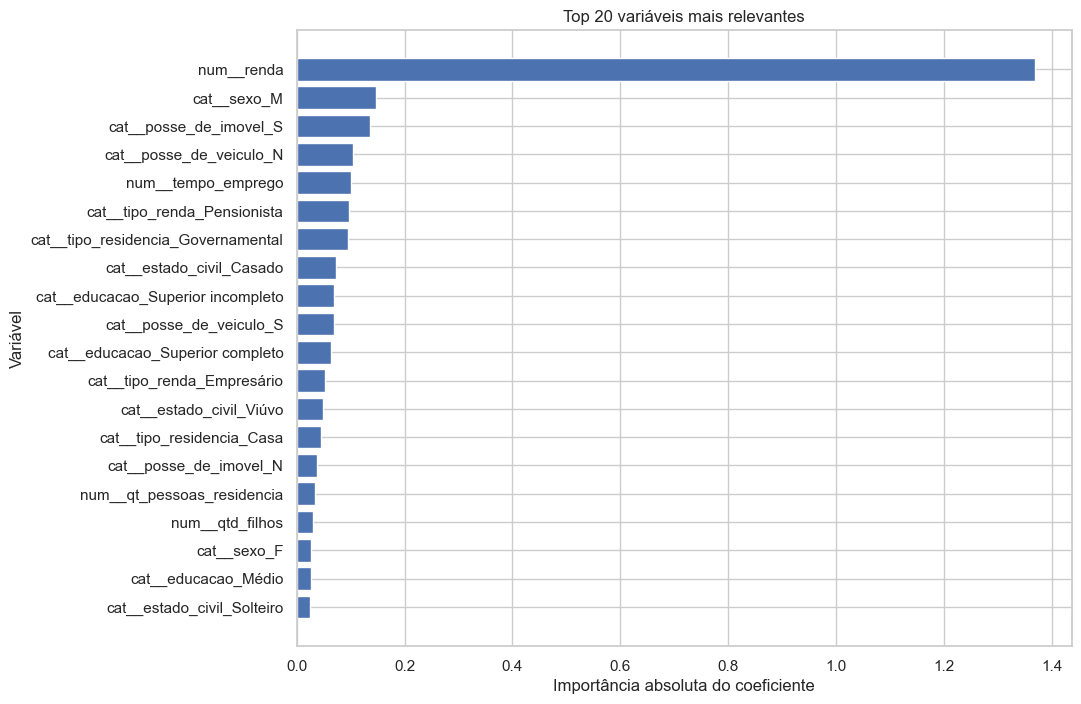

In [33]:
# Gráfico das variáveis mais relevantes

top_importancia = coef_importancia.head(20).sort_values('abs_coef')

plt.figure(figsize=(10, 8))
plt.barh(top_importancia['variavel'], top_importancia['abs_coef'])
plt.title('Top 20 variáveis mais relevantes')
plt.xlabel('Importância absoluta do coeficiente')
plt.ylabel('Variável')
plt.show()

### Redução de dimensionalidade (PCA)

Aplicar PCA para reduzir a dimensionalidade para 5

In [34]:
# Criando um pré-processamento para aplicar PCA

try:
    onehot = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown='ignore', sparse=False)

preprocessador_pca = ColumnTransformer(transformers=[
    ('num', Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('outliers', LimitadorOutliers()),
        ('scaler', StandardScaler())
    ]), variaveis_numericas),
    
    ('cat', Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', onehot)
    ]), variaveis_categoricas)
])

X_train_preparado = preprocessador_pca.fit_transform(X_train)
X_test_preparado = preprocessador_pca.transform(X_test)

print('Dimensão antes do PCA:', X_train_preparado.shape)


Dimensão antes do PCA: (420000, 32)


In [35]:
# Aplicando PCA com 5 componentes

pca = PCA(n_components=5, random_state=42)

X_train_pca = pca.fit_transform(X_train_preparado)
X_test_pca = pca.transform(X_test_preparado)

variancia_pca = pd.DataFrame({
    'componente': ['PC1', 'PC2', 'PC3', 'PC4', 'PC5'],
    'variancia_explicada': pca.explained_variance_ratio_,
    'variancia_acumulada': pca.explained_variance_ratio_.cumsum()
})

print('Variância explicada pelos 5 componentes principais:')
variancia_pca

Variância explicada pelos 5 componentes principais:


,componente,variancia_explicada,variancia_acumulada
0,PC1,0.278837,0.278837
1,PC2,0.201026,0.479864
2,PC3,0.106748,0.586612
3,PC4,0.070954,0.657565
4,PC5,0.056934,0.714499


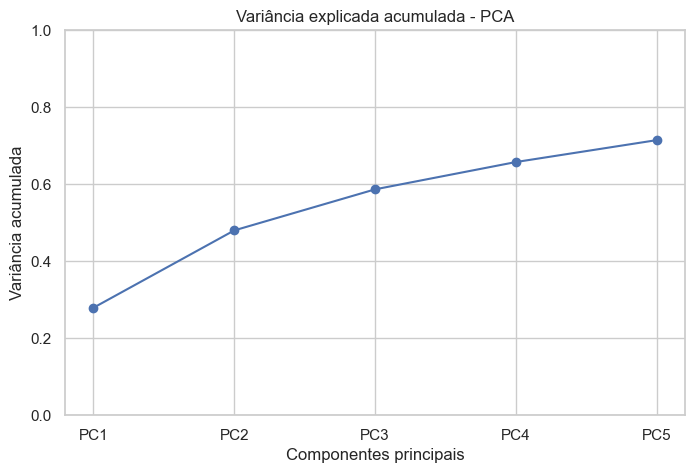

In [36]:
# Gráfico da variância explicada acumulada

plt.figure(figsize=(8, 5))
plt.plot(variancia_pca['componente'], variancia_pca['variancia_acumulada'], marker='o')
plt.title('Variância explicada acumulada - PCA')
plt.xlabel('Componentes principais')
plt.ylabel('Variância acumulada')
plt.ylim(0, 1)
plt.grid(True)
plt.show()

### Criação de dummies

Aplicar o get_dummies() ou onehotencoder() para transformar colunas catégoricas do dataframe em colunas de 0 e 1. 
- sexo
- posse_de_veiculo
- posse_de_imovel
- tipo_renda
- educacao
- estado_civil
- tipo_residencia

In [37]:
# Exemplo de criação de dummy para a variável posse_de_veiculo

dummy_veiculo = pd.get_dummies(X_dev['posse_de_veiculo'], prefix='posse_de_veiculo', drop_first=True)

print('Dummy criada para posse_de_veiculo:')
dummy_veiculo.head()

Dummy criada para posse_de_veiculo:


,posse_de_veiculo_S
0,False
1,True
2,False
3,False
4,True


In [38]:
# Exemplo geral usando OneHotEncoder dentro do pipeline

try:
    encoder_dummies = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    encoder_dummies = OneHotEncoder(handle_unknown='ignore', sparse=False)

encoder_dummies.fit(X_train[variaveis_categoricas])

nomes_dummies = encoder_dummies.get_feature_names_out(variaveis_categoricas)

print('Exemplo de colunas criadas pelo OneHotEncoder:')
print(nomes_dummies[:20])

Exemplo de colunas criadas pelo OneHotEncoder:
['sexo_F' 'sexo_M' 'posse_de_veiculo_N' 'posse_de_veiculo_S'
 'posse_de_imovel_N' 'posse_de_imovel_S' 'tipo_renda_Assalariado'
 'tipo_renda_Bolsista' 'tipo_renda_Empresário' 'tipo_renda_Pensionista'
 'tipo_renda_Servidor público' 'educacao_Fundamental' 'educacao_Médio'
 'educacao_Pós graduação' 'educacao_Superior completo'
 'educacao_Superior incompleto' 'estado_civil_Casado'
 'estado_civil_Separado' 'estado_civil_Solteiro' 'estado_civil_União']


### Pipeline 

Crie um pipeline contendo essas funções.

preprocessamento()
- substituicao de nulos
- remoção outliers
- PCA
- Criação de dummy de pelo menos 1 variável (posse_de_veiculo)

In [39]:
# Criando o pipeline completo solicitado na atividade

pipeline_sklearn = Pipeline(steps=[
    ('preprocessador', ColumnTransformer(transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('outliers', LimitadorOutliers()),
            ('scaler', StandardScaler())
        ]), variaveis_numericas),
        
        ('cat', Pipeline(steps=[
            ('agrupador_raras', AgrupadorCategoriasRaras(limite=0.02)),
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', onehot)
        ]), variaveis_categoricas)
    ])),
    
    ('pca', PCA(n_components=5, random_state=42)),
    
    ('modelo', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

pipeline_sklearn.fit(X_train, y_train)

print('Pipeline completo criado e treinado com sucesso.')

Pipeline completo criado e treinado com sucesso.


In [40]:
# Avaliando o pipeline na base de teste e OOT

proba_test_pipeline = pipeline_sklearn.predict_proba(X_test)[:, 1]
proba_oot_pipeline = pipeline_sklearn.predict_proba(X_oot)[:, 1]

metricas_pipeline = pd.DataFrame({
    'Teste': calcular_metricas(y_test, proba_test_pipeline),
    'OOT': calcular_metricas(y_oot, proba_oot_pipeline)
}).T

print('Métricas do pipeline sklearn:')
metricas_pipeline

Métricas do pipeline sklearn:


,Acurácia,AUC,Gini,KS
Teste,0.570572,0.724333,0.448666,0.330135
OOT,0.429047,0.676536,0.353072,0.257127


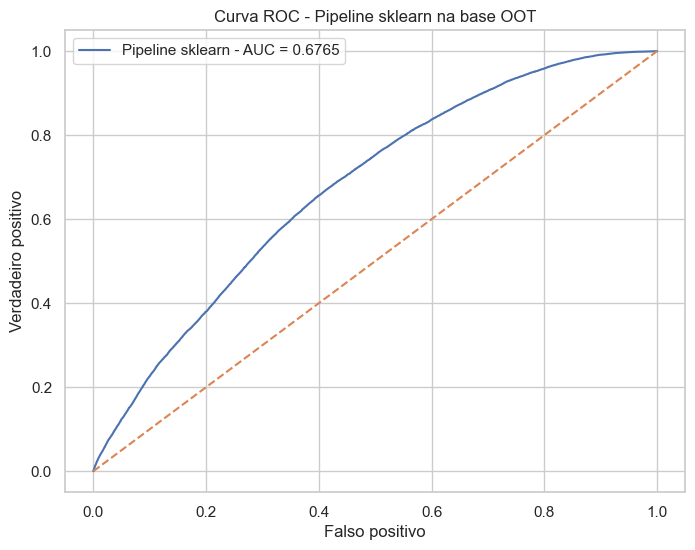

In [41]:
# Curva ROC do pipeline na base OOT

fpr_pipe, tpr_pipe, _ = roc_curve(y_oot, proba_oot_pipeline)
auc_pipe = roc_auc_score(y_oot, proba_oot_pipeline)

plt.figure(figsize=(8, 6))
plt.plot(fpr_pipe, tpr_pipe, label=f'Pipeline sklearn - AUC = {auc_pipe:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title('Curva ROC - Pipeline sklearn na base OOT')
plt.xlabel('Falso positivo')
plt.ylabel('Verdadeiro positivo')
plt.legend()
plt.show()

### Treinar um modelo de regressão logistica com o resultado

In [42]:
# Treinando uma regressão logística com pré-processamento completo

# Separando variáveis numéricas e categóricas
variaveis_numericas = X_train.select_dtypes(include=['int64', 'int32', 'float64', 'float32']).columns.tolist()
variaveis_categoricas = X_train.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print('Variáveis numéricas:')
print(variaveis_numericas)

print('\nVariáveis categóricas:')
print(variaveis_categoricas)

# Criando o OneHotEncoder compatível com versões diferentes do sklearn
try:
    onehot = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown='ignore', sparse=False)

# Criando o preprocessador completo
preprocessador = ColumnTransformer(transformers=[
    ('num', Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), variaveis_numericas),

    ('cat', Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', onehot)
    ]), variaveis_categoricas)
])

# Criando o modelo final
modelo_final = Pipeline(steps=[
    ('preprocessador', preprocessador),
    ('modelo', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

# Treinando o modelo
modelo_final.fit(X_train, y_train)

print('Modelo de regressão logística treinado com sucesso.')

Variáveis numéricas:
['qtd_filhos', 'idade', 'tempo_emprego', 'qt_pessoas_residencia', 'renda']

Variáveis categóricas:
['sexo', 'posse_de_veiculo', 'posse_de_imovel', 'tipo_renda', 'educacao', 'estado_civil', 'tipo_residencia']
Modelo de regressão logística treinado com sucesso.


### Salvar o pickle file do modelo treinado

In [43]:
# Salvando o modelo final em pickle

import pickle

nome_arquivo = 'model_final.pkl'

with open(nome_arquivo, 'wb') as arquivo:
    pickle.dump(modelo_final, arquivo)

print('Modelo salvo como model_final.pkl')

Modelo salvo como model_final.pkl


# Pycaret na base de dados 

Utilize o pycaret para pre processar os dados e rodar o modelo **lightgbm**. Faça todos os passos a passos da aula e gere os gráficos finais. E o pipeline de toda a transformação.



In [44]:
from pycaret.classification import *

In [45]:
import pandas as pd

df = pd.read_feather('credit_scoring.ftr')

print('Dimensão da base:', df.shape)
df.head()

Dimensão da base: (750000, 15)


,data_ref,index,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,renda,mau
0,2015-01-01,5733,F,N,N,0,Empresário,Médio,Solteiro,Casa,43,6.873973,1.0,2515.39,False
1,2015-01-01,727,F,S,S,0,Assalariado,Médio,Casado,Casa,35,4.526027,2.0,3180.19,False
2,2015-01-01,6374,F,N,N,2,Assalariado,Médio,Casado,Casa,31,0.243836,4.0,1582.29,False
3,2015-01-01,9566,F,N,N,0,Assalariado,Médio,Casado,Casa,54,12.772603,2.0,13721.17,False
4,2015-01-01,9502,F,S,N,0,Assalariado,Superior incompleto,Solteiro,Casa,31,8.432877,1.0,2891.08,False


In [46]:
dataset = df.sample(50000, random_state=42)

dataset.drop(['data_ref', 'index'], axis=1, inplace=True)

data = dataset.sample(frac=0.95, random_state=786)
data_unseen = dataset.drop(data.index)

data.reset_index(inplace=True, drop=True)
data_unseen.reset_index(inplace=True, drop=True)

print('Conjunto de dados para modelagem:', data.shape)
print('Conjunto de dados não vistos:', data_unseen.shape)

data.head()

Conjunto de dados para modelagem: (47500, 13)
Conjunto de dados não vistos: (2500, 13)


,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,renda,mau
0,M,S,N,0,Assalariado,Médio,Casado,Casa,45,11.106849,2.0,38003.82,False
1,F,N,N,0,Servidor público,Superior completo,Casado,Casa,60,14.353425,2.0,114305.63,False
2,M,S,N,1,Servidor público,Superior completo,Casado,Casa,35,9.791781,3.0,22011.06,False
3,M,S,N,0,Assalariado,Médio,Casado,Casa,52,10.030137,2.0,25078.07,False
4,F,N,S,0,Pensionista,Fundamental,Casado,Casa,61,NaN,2.0,11493.42,False


In [47]:
from pycaret.classification import *

exp_clf = setup(
    data=data,
    target='mau',
    session_id=123,
    normalize=True,
    normalize_method='zscore'
)

,Description,Value
0,Session id,123
1,Target,mau
2,Target type,Binary
3,Original data shape,"(47500, 13)"
4,Transformed data shape,"(47500, 30)"
5,Transformed train set shape,"(33250, 30)"
6,Transformed test set shape,"(14250, 30)"
7,Numeric features,5
8,Categorical features,7
9,Rows with missing values,16.8%


### Modelagem com LightGBM no PyCaret

In [48]:
models()

,Name,Reference,Turbo
ID,,,
lr,Logistic Regression,sklearn.linear_model._logistic.LogisticRegression,True
knn,K Neighbors Classifier,sklearn.neighbors._classification.KNeighborsCl...,True
nb,Naive Bayes,sklearn.naive_bayes.GaussianNB,True
dt,Decision Tree Classifier,sklearn.tree._classes.DecisionTreeClassifier,True
svm,SVM - Linear Kernel,sklearn.linear_model._stochastic_gradient.SGDC...,True
rbfsvm,SVM - Radial Kernel,sklearn.svm._classes.SVC,False
gpc,Gaussian Process Classifier,sklearn.gaussian_process._gpc.GaussianProcessC...,False
mlp,MLP Classifier,sklearn.neural_network._multilayer_perceptron....,False
ridge,Ridge Classifier,sklearn.linear_model._ridge.RidgeClassifier,True


In [49]:
lightgbm = create_model('lightgbm', fold=5)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9206,0.7586,0.0152,0.4211,0.0294,0.0240,0.0679
1,0.9206,0.7613,0.0267,0.4516,0.0504,0.0419,0.0946
2,0.9209,0.7562,0.0267,0.4828,0.0505,0.0426,0.0991
3,0.9198,0.7616,0.0380,0.4255,0.0698,0.0576,0.1083
4,0.9200,0.7707,0.0228,0.4000,0.0432,0.0349,0.0800
Mean,0.9204,0.7617,0.0259,0.4362,0.0487,0.0402,0.0900
Std,0.0004,0.0049,0.0074,0.0285,0.0131,0.0110,0.0143


In [50]:
tuned_lightgbm = tune_model(lightgbm, optimize='AUC', fold=5)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9211,0.7738,0.0000,0.0000,0.0000,0.0000,0.0000
1,0.9211,0.7738,0.0000,0.0000,0.0000,0.0000,0.0000
2,0.9211,0.7637,0.0000,0.0000,0.0000,0.0000,0.0000
3,0.9209,0.7743,0.0000,0.0000,0.0000,0.0000,0.0000
4,0.9209,0.7867,0.0000,0.0000,0.0000,0.0000,0.0000
Mean,0.9210,0.7745,0.0000,0.0000,0.0000,0.0000,0.0000
Std,0.0001,0.0073,0.0000,0.0000,0.0000,0.0000,0.0000


Fitting 5 folds for each of 10 candidates, totalling 50 fits


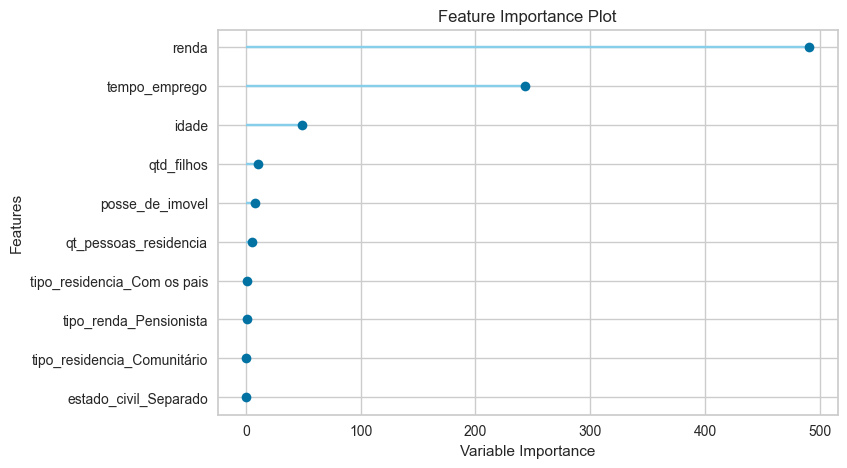

In [51]:
plot_model(tuned_lightgbm, plot='feature')

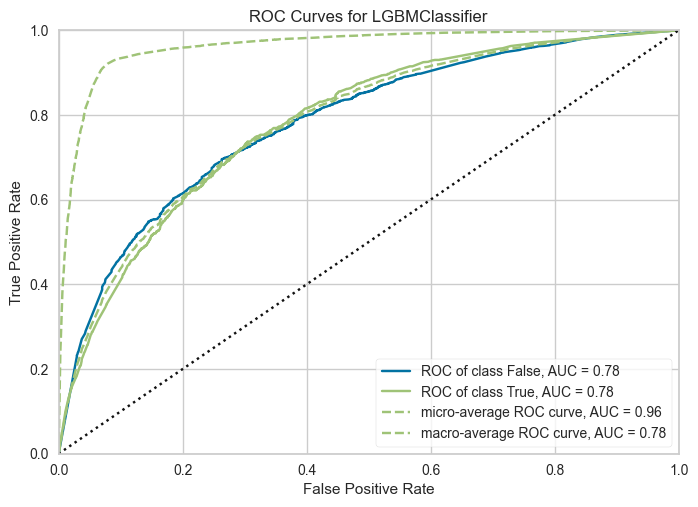

In [52]:
plot_model(tuned_lightgbm, plot='auc')

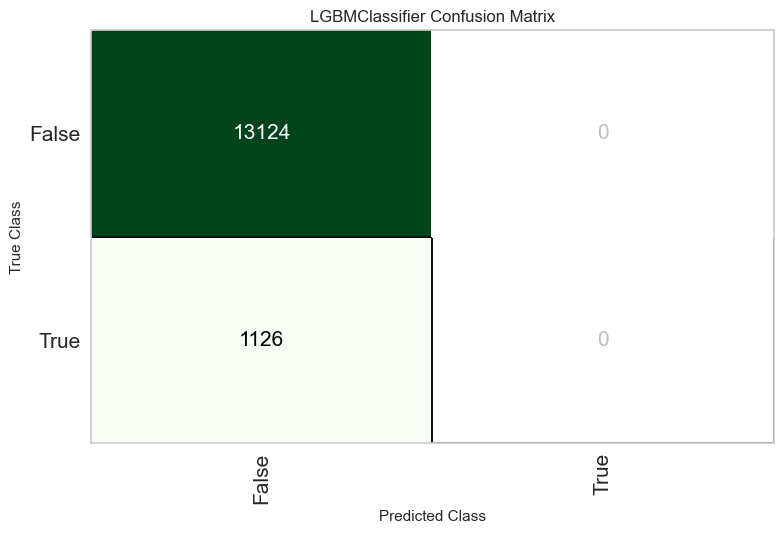

In [53]:
plot_model(tuned_lightgbm, plot='confusion_matrix')

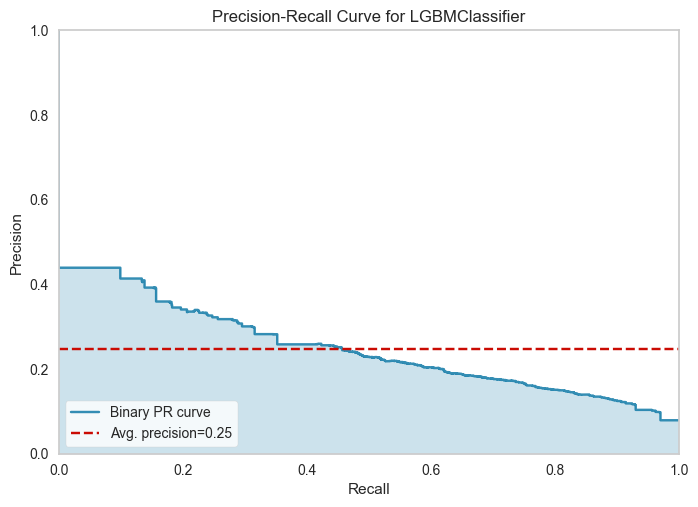

In [54]:
plot_model(tuned_lightgbm, plot='pr')

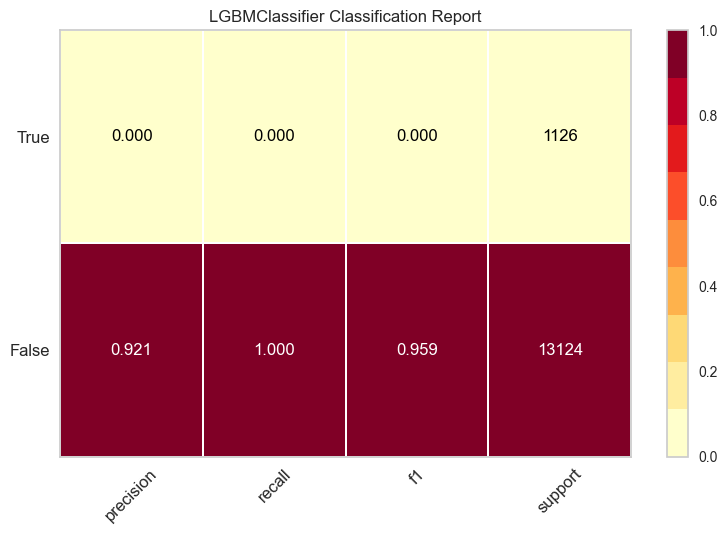

In [55]:
plot_model(tuned_lightgbm, plot='class_report')

In [56]:
final_lightgbm = finalize_model(tuned_lightgbm)

unseen_predictions = predict_model(final_lightgbm, data=data_unseen)

print('Previsões na base não vista:')
unseen_predictions.head()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.9268,0.7812,0.0000,0.0000,0.0000,0.0000,0.0000


[LightGBM] [Warning] feature_fraction is set=1.0, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1.0
[LightGBM] [Warning] bagging_fraction is set=0.6, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] feature_fraction is set=1.0, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1.0
[LightGBM] [Warning] bagging_fraction is set=0.6, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
Previsões na base não vista:


,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,renda,mau,prediction_label,prediction_score
0,F,N,N,1,Assalariado,Médio,Casado,Casa,40,11.328767,3.0,11635.209961,False,0,0.921
1,F,N,S,0,Pensionista,Superior completo,Solteiro,Casa,58,NaN,1.0,4563.459961,False,0,0.921
2,M,N,S,0,Empresário,Médio,Casado,Casa,34,11.065753,2.0,24880.080078,False,0,0.921
3,M,N,S,0,Assalariado,Médio,Solteiro,Casa,27,3.016438,1.0,3876.590088,False,0,0.921
4,F,N,N,0,Servidor público,Médio,Casado,Com os pais,33,0.536986,2.0,1139.979980,True,0,0.921


### Salvando o modelo final do PyCaret

In [57]:
save_model(final_lightgbm, 'Final LightGBM Credit Scoring')

saved_final_lightgbm = load_model('Final LightGBM Credit Scoring')

print('Modelo salvo e carregado com sucesso.')

Transformation Pipeline and Model Successfully Saved
Transformation Pipeline and Model Successfully Loaded
Modelo salvo e carregado com sucesso.


In [58]:
saved_final_lightgbm

Pipeline(memory=FastMemory(location=C:\Users\Priscila\AppData\Local\Temp\joblib),
         steps=[('numerical_imputer',
                 TransformerWrapper(exclude=None,
                                    include=['qtd_filhos', 'idade',
                                             'tempo_emprego',
                                             'qt_pessoas_residencia', 'renda'],
                                    transformer=SimpleImputer(add_indicator=False,
                                                              copy=True,
                                                              fill_value=None,
                                                              keep_empty_features=False,
                                                              missing_values=nan,
                                                              strategy='mea...
                                boosting_type='gbdt', class_weight=None,
                                colsample_bytree=1.0, feature_fraction=1.0,
                                importance_type='split', learning_rate=1e-07,
                                max_depth=-1, min_child_samples=1,
                                min_child_weight=0.001, min_split_gain=0.5,
                                n_estimators=90, n_jobs=-1, num_leaves=10,
                                objective=None, random_state=123, reg_alpha=10,
                                reg_lambda=2, subsample=1.0,
                                subsample_for_bin=200000, subsample_freq=0))],
         verbose=False)

### Salvar o arquivo do modelo treinado

In [60]:
# Criando uma base CSV de teste para usar no Streamlit

df_teste_app = df.drop(columns=['mau', 'data_ref', 'index'], errors='ignore').head(100)

df_teste_app.to_csv('base_teste_app.csv', index=False)

print('Arquivo base_teste_app.csv criado com sucesso.')

Arquivo base_teste_app.csv criado com sucesso.


# Projeto Final

1. Subir no GITHUB todos os jupyter notebooks/códigos que você desenvolveu nesse ultimo módulo
1. Gerar um arquivo python (.py) com todas as funções necessárias para rodar no streamlit a escoragem do arquivo de treino
    - Criar um .py
    - Criar um carregador de csv no streamlit 
    - Subir um csv no streamlit 
    - Criar um pipeline de pré processamento dos dados
    - Utilizar o modelo treinado para escorar a base 
        - nome_arquivo = 'model_final.pkl'
1. Gravar um vídeo da tela do streamlit em funcionamento (usando o próprio streamlit (temos aula disso) ou qlqr outra forma de gravação).
1. Subir no Github o vídeo de funcionamento da ferramenta como README.md.
1. Subir no Github os códigos desenvolvidos. 
1. Enviar links do github para o tutor corrigir.